In [15]:
import os
import joblib
from IPython.display import display, Latex

from sklearn.metrics import f1_score, multilabel_confusion_matrix, \
    classification_report, accuracy_score, hamming_loss

import numpy as np
import matplotlib.pyplot as plt

import torch

# LLR6 vanilla

## Datasets

In [2]:
cwd = os.getcwd()

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']
datasets_ids = list(range(1, len(datasets) + 1))

In [3]:
model_name = 'llr6'  # 'llr6' or 'nn2'
og_model = True      # True = llr6, False = tt 
scaler_type = 'standard' # 'standard' or 'minimax'
model_type = 'vanilla' # 'vanilla' or 'average'

aux_dir = 'datasets' if og_model else 'tt_datasets'
dataset_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type,
                           'params_multilabel.pt')

all_labels, all_params, all_bal_accs, all_auc_scores = \
    torch.load(dataset_dir, weights_only=True)

### Accuracies on train/test

In [4]:
cond = (all_labels == torch.tensor([1, 0, 0, 0, 0, 0, 0, 0, 0])).all(dim=1)

In [5]:
all_labels[cond]

tensor([[1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        ...,
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0]], dtype=torch.int32)

In [6]:
all_params[cond][200:300, :][0]

tensor([ 4.1880e-02, -7.5578e-01,  5.2582e-01, -3.2770e-02,  1.7373e-03,
        -3.3464e-01, -4.6585e-01, -4.3904e-01,  1.1167e-01,  5.7964e-01,
         1.8843e-01,  8.4085e-02, -3.0920e-02,  0.0000e+00,  5.1239e-01,
        -1.5643e-02,  0.0000e+00, -1.1611e+00,  5.2785e-01,  0.0000e+00,
         0.0000e+00, -1.9501e+00], dtype=torch.float64)

In [7]:
# Evaluate on Chowell_test
for iC, C in enumerate([0.1, 1.0, 10.0]):
    for il1, l1 in enumerate([0.0, 0.5, 1.0]):
        i = 3 * iC + il1
        aux = all_auc_scores[cond][(i*100):((i+1)*100), 1]
        if (l1 == 1.0) and (C == 0.1):
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f} <--')
        else:
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f}')

C=0.1 , l1=0.0, mean: 0.7475, std: 0.0064
C=0.1 , l1=0.5, mean: 0.7497, std: 0.0059
C=0.1 , l1=1.0, mean: 0.7519, std: 0.0037 <--
C=1.0 , l1=0.0, mean: 0.7475, std: 0.0065
C=1.0 , l1=0.5, mean: 0.7475, std: 0.0063
C=1.0 , l1=1.0, mean: 0.7479, std: 0.0064
C=10.0, l1=0.0, mean: 0.7473, std: 0.0056
C=10.0, l1=0.5, mean: 0.7479, std: 0.0063
C=10.0, l1=1.0, mean: 0.7475, std: 0.0067


In [8]:
# Evaluate on Chowell_train
for iC, C in enumerate([0.1, 1.0, 10.0]):
    for il1, l1 in enumerate([0.0, 0.5, 1.0]):
        i = 3 * iC + il1
        aux = all_auc_scores[cond][(i*100):((i+1)*100), 0]
        if (l1 == 1.0) and (C == 0.1):
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f} <--')
        else:
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f}')

C=0.1 , l1=0.0, mean: 0.7412, std: 0.0021
C=0.1 , l1=0.5, mean: 0.7408, std: 0.0022
C=0.1 , l1=1.0, mean: 0.7381, std: 0.0024 <--
C=1.0 , l1=0.0, mean: 0.7412, std: 0.0023
C=1.0 , l1=0.5, mean: 0.7410, std: 0.0022
C=1.0 , l1=1.0, mean: 0.7411, std: 0.0020
C=10.0, l1=0.0, mean: 0.7411, std: 0.0017
C=10.0, l1=0.5, mean: 0.7411, std: 0.0021
C=10.0, l1=1.0, mean: 0.7408, std: 0.0023


### Accuracies on all datasets

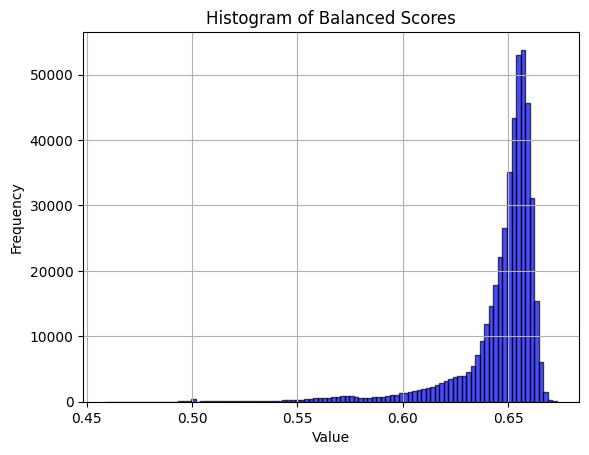

In [9]:
# Plot histogram scores
plt.hist(all_bal_accs[:, -1].numpy(), bins=100, alpha=0.7,
         color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Balanced Scores")
plt.grid(True)

# Show plot
plt.show()

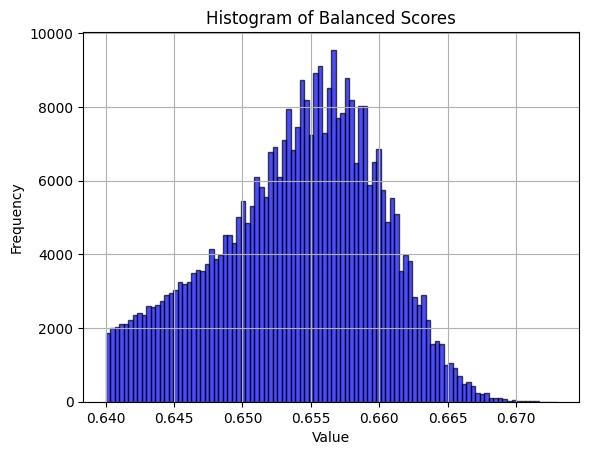

In [10]:
# Plot histogram scores
# idx = (all_bal_accs >= 0.55).all(dim=1)
idx = (all_bal_accs[:, -1] >= 0.64)
filtered_scores = all_bal_accs[idx]
plt.hist(filtered_scores[:, -1].numpy(), bins=100, alpha=0.7,
         color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Balanced Scores")
plt.grid(True)

# Show plot
plt.show()

In [11]:
lower_bound = 0.64

# idx = (all_bal_accs >= lower_bound).all(dim=1)
idx = (all_bal_accs[:, -1] >= lower_bound)

all_labels = all_labels[idx]
all_params = all_params[idx]
all_bal_accs = all_bal_accs[idx]
all_auc_scores = all_auc_scores[idx]

## Black-box attacks

### Weak (balanced accuracies)

In [12]:
attack_name = 'weak'

aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
mlp_bb = joblib.load(
    os.path.join(attack_model_dir,
                 f'mlp_attacker_multilabel_bb_{attack_name}.pkl'))
X_test, y_test = joblib.load(
    os.path.join(attack_model_dir,
                 f'heldout_test_set_bb_{attack_name}.pkl'))

In [13]:
# Predict probabilities and binary labels
y_pred = mlp_bb.predict(X_test)

ham = hamming_loss(y_test, y_pred)
print(f"Accuracy: {1 - ham:.4f}")

# Evaluate using F1-score
print("F1-score:", f1_score(y_test, y_pred, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.7521
F1-score: 0.7762652450748239

Confusion Matrix for Class 0 - Chowell_train:
[[0.84206072 0.15793928]
 [0.05361884 0.94638116]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.80459347 0.19540653]
 [0.07670998 0.92329002]]

Confusion Matrix for Class 2 - MSK1:
[[0.76226415 0.23773585]
 [0.07838556 0.92161444]]

Confusion Matrix for Class 3 - MSK2:
[[0.71721334 0.28278666]
 [0.15114347 0.84885653]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.6435944  0.3564056 ]
 [0.31756684 0.68243316]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.43685998 0.56314002]
 [0.26646754 0.73353246]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.58723107 0.41276893]
 [0.34423591 0.65576409]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.72873333 0.27126667]
 [0.19351562 0.80648437]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.74634656 0.25365344]
 [0.32586892 0.67413108]]


              precision    recall  f1-score   support

           0       0.91      0.95   

### Strong (AUC scores)

In [14]:
attack_name = 'strong'

aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
mlp_bb = joblib.load(
    os.path.join(attack_model_dir,
                 f'mlp_attacker_multilabel_bb_{attack_name}.pkl'))
X_test, y_test = joblib.load(
    os.path.join(attack_model_dir,
                 f'heldout_test_set_bb_{attack_name}.pkl'))

In [15]:
# Predict probabilities and binary labels
y_pred = mlp_bb.predict(X_test)

ham = hamming_loss(y_test, y_pred)
print(f"Accuracy: {1 - ham:.4f}")

# Evaluate using F1-score
print("F1-score:", f1_score(y_test, y_pred, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.7999
F1-score: 0.8161078289501712

Confusion Matrix for Class 0 - Chowell_train:
[[0.99590959 0.00409041]
 [0.00894373 0.99105627]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.93083044 0.06916956]
 [0.00752235 0.99247765]]

Confusion Matrix for Class 2 - MSK1:
[[0.75290447 0.24709553]
 [0.01687245 0.98312755]]

Confusion Matrix for Class 3 - MSK2:
[[0.64238229 0.35761771]
 [0.22869352 0.77130648]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.80654512 0.19345488]
 [0.28441176 0.71558824]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.58313188 0.41686812]
 [0.32524401 0.67475599]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.58695166 0.41304834]
 [0.31651221 0.68348779]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.75827695 0.24172305]
 [0.16247396 0.83752604]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.88170668 0.11829332]
 [0.23457339 0.76542661]]


              precision    recall  f1-score   support

           0       1.00      0.99   

## White-box attack ensemble

In [16]:
aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name,
                                scaler_type, model_type)
X_test, y_test = joblib.load(os.path.join(attack_model_dir,
                                          'heldout_test_set_wb.pkl'))

# Load models
n_splits = 5
loaded_models = []

# Load each model
for fold in range(1, n_splits + 1):
    model_path = os.path.join(attack_model_dir,
                              f'mlp_attacker_multilabel_wb_fold_{fold}.pkl')
    model = joblib.load(model_path)
    loaded_models.append(model)

In [17]:
# Multilabel: average predictions and apply threshold
all_preds = np.array([model.predict_proba(X_test) for model in loaded_models])
avg_preds = np.mean(all_preds, axis=0)
final_preds = (avg_preds >= 0.5).astype(int)

# Accuracy (or any other metric)
# acc = accuracy_score(y_test, final_preds)
# print(f"Ensemble accuracy: {acc:.4f}")
ham = hamming_loss(y_test, final_preds)
print(f"Ensemble accuracy: {1 - ham:.4f}")

Ensemble accuracy: 0.9168


In [18]:
# Evaluate using F1-score
print("F1-score:", f1_score(y_test, final_preds, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, final_preds)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, final_preds, zero_division=0))

F1-score: 0.9226125396785654

Confusion Matrix for Class 0 - Chowell_train:
[[9.97990056e-01 2.00994393e-03]
 [5.22261392e-04 9.99477739e-01]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.9912744  0.0087256 ]
 [0.00560798 0.99439202]]

Confusion Matrix for Class 2 - MSK1:
[[0.96523548 0.03476452]
 [0.01581485 0.98418515]]

Confusion Matrix for Class 3 - MSK2:
[[0.98783034 0.01216966]
 [0.01255572 0.98744428]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.85438734 0.14561266]
 [0.14470588 0.85529412]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.79652316 0.20347684]
 [0.26468078 0.73531922]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.69631182 0.30368818]
 [0.12831296 0.87168704]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.91287278 0.08712722]
 [0.02723958 0.97276042]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.95472338 0.04527662]
 [0.06629067 0.93370933]]


              precision    recall  f1-score   support

           0       1.00      1.00    

### Evaluate LORIS

In [19]:
def classify_by_dataset(models, params):
    # Multilabel: average predictions and apply threshold
    all_preds = np.array([model.predict_proba(params) for model in models])
    avg_preds = np.mean(all_preds, axis=0)
    
    
    for i in range(len(datasets)):
        print(f'{datasets[i]:>16}: {avg_preds[0][i]:.4f}')

In [20]:
# ['TMB', 'Systemic_therapy_history', 'Albumin', 'NLR', 'Age',
#  'CancerType1', 'CancerType2', 'CancerType3', 'CancerType4',
#  'CancerType5', 'CancerType6', 'CancerType7', 'CancerType8',
#  'CancerType9', 'CancerType10', 'CancerType11', 'CancerType12',
#  'CancerType13', 'CancerType14', 'CancerType15', 'CancerType16']

# S = 0.0371 * min(TMB, 50) - 0.8775 * PSTH + 0.5382 * Albumin - 0.033 * min(NLR, 25) + 0.0049 * min(Age, 85) + CTCT - 2.0886

# CTCT = - 0.3323 * Bladder - 0.3323 * Breast - 0.102 * Colorectal - 0.0079 * Endometrial + 0.55 * Esophageal + 0.2306 * Gastric
#     + 0.0678 * Head&Neck - 0.1189 * Hepatobiliary - 0.0086 * Melanoma + 0.1255 * Mesothelioma + 0.0008 * NSCLC
#     - 0.052 * Ovarian - 1.1169 * Pancreatic + 0.5451 * Renal + 0.0542 * Sarcoma - 0.0033 * SCLC

coeffs = [0.0371, -0.8775, 0.5382, -0.033, 0.0049, -0.3323, -0.3323, -0.102,
          -0.0079, 0.55, 0.2306, 0.0678, -0.1189, -0.0086, 0.1255, 0.0008,
          -0.052, -1.1169, 0.5451, 0.0542, -0.0033, -2.0886]
X_loris = torch.tensor(coeffs).unsqueeze(0)
X_loris

tensor([[ 3.7100e-02, -8.7750e-01,  5.3820e-01, -3.3000e-02,  4.9000e-03,
         -3.3230e-01, -3.3230e-01, -1.0200e-01, -7.9000e-03,  5.5000e-01,
          2.3060e-01,  6.7800e-02, -1.1890e-01, -8.6000e-03,  1.2550e-01,
          8.0000e-04, -5.2000e-02, -1.1169e+00,  5.4510e-01,  5.4200e-02,
         -3.3000e-03, -2.0886e+00]])

In [21]:
classify_by_dataset(loaded_models, X_loris)

   Chowell_train: 1.0000
    Chowell_test: 0.0097
            MSK1: 0.0333
            MSK2: 0.1326
      Shim_NSCLC: 0.0667
  Kato_panCancer: 0.2923
   Vanguri_NSCLC: 0.5164
      Ravi_NSCLC: 0.0064
Pradat_panCancer: 0.0230


### Check other models

In [22]:
aux_datasets = [0, 4, 5]
cond1 = y_test.sum(dim=1) == len(aux_datasets)
cond2 = y_test[:, aux_datasets].all(dim=1)
aux_params = X_test[cond1 * cond2]

print(aux_params.shape)
idx = torch.randperm(aux_params.shape[0])[0]
aux_coeffs = aux_params[idx].unsqueeze(0)
aux_coeffs

torch.Size([185, 22])


tensor([[ 0.0388, -0.7423,  0.4946, -0.0507,  0.0154, -0.7082, -0.3587, -0.3585,
          0.0000,  0.8623,  0.4730,  0.3956, -0.3926,  0.0000,  0.4805,  0.0483,
          0.0000, -1.8559,  0.7962,  0.0000, -0.3676, -2.5667]],
       dtype=torch.float64)

In [23]:
classify_by_dataset(loaded_models, aux_coeffs)

   Chowell_train: 1.0000
    Chowell_test: 0.0266
            MSK1: 0.2166
            MSK2: 0.0412
      Shim_NSCLC: 0.9891
  Kato_panCancer: 0.5988
   Vanguri_NSCLC: 0.5067
      Ravi_NSCLC: 0.0000
Pradat_panCancer: 0.0194


# LLR6 average

## Datasets

In [24]:
cwd = os.getcwd()

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']
datasets_ids = list(range(1, len(datasets) + 1))

In [25]:
model_name = 'llr6'  # 'llr6' or 'nn2'
og_model = True      # True = llr6, False = tt 
scaler_type = 'standard' # 'standard' or 'minimax'
model_type = 'average' # 'vanilla' or 'average'

aux_dir = 'datasets' if og_model else 'tt_datasets'
dataset_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type,
                           'params_multilabel.pt')

all_labels, all_params, all_bal_accs, all_auc_scores = \
    torch.load(dataset_dir, weights_only=True)

### Accuracies on train/test

In [26]:
cond = (all_labels == torch.tensor([1, 0, 0, 0, 0, 0, 0, 0, 0])).all(dim=1)

In [27]:
all_labels[cond]

tensor([[1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        ...,
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0]], dtype=torch.int32)

In [28]:
all_params[cond][200:300, :][0]

tensor([ 3.5625e-02, -8.6805e-01,  5.1487e-01, -3.0641e-02,  4.4756e-03,
        -2.9795e-01, -2.8235e-01, -7.2376e-02,  2.7089e-03,  4.8952e-01,
         2.0883e-01,  5.7606e-02, -1.2260e-01, -8.6673e-03,  9.3944e-02,
         7.2984e-04, -6.2564e-02, -9.0208e-01,  4.9290e-01,  5.7316e-02,
        -1.0378e-02, -1.9780e+00], dtype=torch.float64)

In [29]:
# Evaluate on Chowell_test
for iC, C in enumerate([0.1, 1.0, 10.0]):
    for il1, l1 in enumerate([0.0, 0.5, 1.0]):
        i = 3 * iC + il1
        aux = all_auc_scores[cond][(i*100):((i+1)*100), 1]
        if (l1 == 1.0) and (C == 0.1):
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f} <--')
        else:
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f}')

C=0.1 , l1=0.0, mean: 0.7508, std: 0.0003
C=0.1 , l1=0.5, mean: 0.7527, std: 0.0003
C=0.1 , l1=1.0, mean: 0.7551, std: 0.0005 <--
C=1.0 , l1=0.0, mean: 0.7490, std: 0.0004
C=1.0 , l1=0.5, mean: 0.7496, std: 0.0004
C=1.0 , l1=1.0, mean: 0.7504, std: 0.0004
C=10.0, l1=0.0, mean: 0.7478, std: 0.0005
C=10.0, l1=0.5, mean: 0.7480, std: 0.0005
C=10.0, l1=1.0, mean: 0.7481, std: 0.0006


In [30]:
# Evaluate on Chowell_train
for iC, C in enumerate([0.1, 1.0, 10.0]):
    for il1, l1 in enumerate([0.0, 0.5, 1.0]):
        i = 3 * iC + il1
        aux = all_auc_scores[cond][(i*100):((i+1)*100), 0]
        if (l1 == 1.0) and (C == 0.1):
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f} <--')
        else:
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f}')

C=0.1 , l1=0.0, mean: 0.7442, std: 0.0001
C=0.1 , l1=0.5, mean: 0.7440, std: 0.0001
C=0.1 , l1=1.0, mean: 0.7406, std: 0.0002 <--
C=1.0 , l1=0.0, mean: 0.7437, std: 0.0001
C=1.0 , l1=0.5, mean: 0.7442, std: 0.0001
C=1.0 , l1=1.0, mean: 0.7443, std: 0.0001
C=10.0, l1=0.0, mean: 0.7433, std: 0.0001
C=10.0, l1=0.5, mean: 0.7434, std: 0.0001
C=10.0, l1=1.0, mean: 0.7434, std: 0.0001


### Accuracies on all datasets

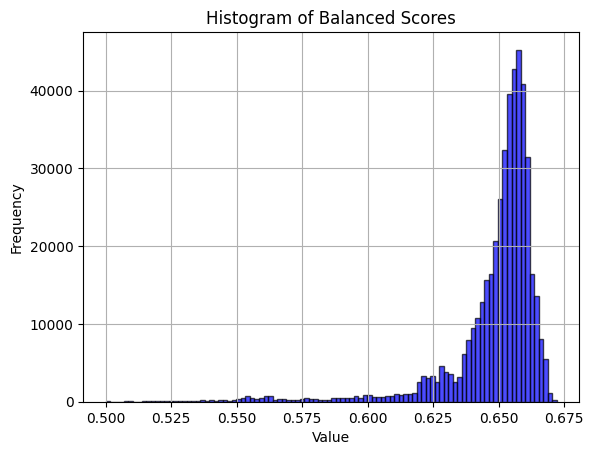

In [31]:
# Plot histogram scores
plt.hist(all_bal_accs[:, -1].numpy(), bins=100, alpha=0.7,
         color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Balanced Scores")
plt.grid(True)

# Show plot
plt.show()

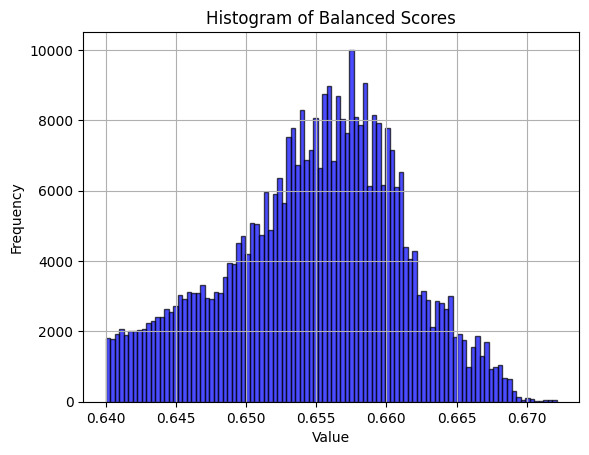

In [32]:
# Plot histogram scores
# idx = (all_bal_accs >= 0.55).all(dim=1)
idx = (all_bal_accs[:, -1] >= 0.64)
filtered_scores = all_bal_accs[idx]
plt.hist(filtered_scores[:, -1].numpy(), bins=100, alpha=0.7,
         color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Balanced Scores")
plt.grid(True)

# Show plot
plt.show()

In [33]:
lower_bound = 0.64

# idx = (all_bal_accs >= lower_bound).all(dim=1)
idx = (all_bal_accs[:, -1] >= lower_bound)

all_labels = all_labels[idx]
all_params = all_params[idx]
all_bal_accs = all_bal_accs[idx]
all_auc_scores = all_auc_scores[idx]

## Black-box attacks

### Weak (balanced accuracies)

In [34]:
attack_name = 'weak'

aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
mlp_bb = joblib.load(
    os.path.join(attack_model_dir,
                 f'mlp_attacker_multilabel_bb_{attack_name}.pkl'))
X_test, y_test = joblib.load(
    os.path.join(attack_model_dir,
                 f'heldout_test_set_bb_{attack_name}.pkl'))

In [35]:
# Predict probabilities and binary labels
y_pred = mlp_bb.predict(X_test)

ham = hamming_loss(y_test, y_pred)
print(f"Accuracy: {1 - ham:.4f}")

# Evaluate using F1-score
print("F1-score:", f1_score(y_test, y_pred, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.8175
F1-score: 0.8332689553689908

Confusion Matrix for Class 0 - Chowell_train:
[[0.93080472 0.06919528]
 [0.00223757 0.99776243]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.94874187 0.05125813]
 [0.04042397 0.95957603]]

Confusion Matrix for Class 2 - MSK1:
[[0.95107955 0.04892045]
 [0.04716562 0.95283438]]

Confusion Matrix for Class 3 - MSK2:
[[0.38524373 0.61475627]
 [0.01641293 0.98358707]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.74722395 0.25277605]
 [0.19698222 0.80301778]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.55474318 0.44525682]
 [0.2707202  0.7292798 ]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.86935987 0.13064013]
 [0.53762792 0.46237208]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.81524231 0.18475769]
 [0.06794134 0.93205866]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.80828539 0.19171461]
 [0.14068112 0.85931888]]


              precision    recall  f1-score   support

           0       0.96      1.00   

### Strong (AUC scores)

In [36]:
attack_name = 'strong'

aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
mlp_bb = joblib.load(
    os.path.join(attack_model_dir,
                 f'mlp_attacker_multilabel_bb_{attack_name}.pkl'))
X_test, y_test = joblib.load(
    os.path.join(attack_model_dir,
                 f'heldout_test_set_bb_{attack_name}.pkl'))

In [37]:
# Predict probabilities and binary labels
y_pred = mlp_bb.predict(X_test)

ham = hamming_loss(y_test, y_pred)
print(f"Accuracy: {1 - ham:.4f}")

# Evaluate using F1-score
print("F1-score:", f1_score(y_test, y_pred, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.8971
F1-score: 0.9062276381422194

Confusion Matrix for Class 0 - Chowell_train:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 1 - Chowell_test:
[[9.99315729e-01 6.84271096e-04]
 [3.99139632e-04 9.99600860e-01]]

Confusion Matrix for Class 2 - MSK1:
[[9.98492972e-01 1.50702797e-03]
 [1.40373862e-04 9.99859626e-01]]

Confusion Matrix for Class 3 - MSK2:
[[0.71216782 0.28783218]
 [0.23878408 0.76121592]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.98344749 0.01655251]
 [0.01147168 0.98852832]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.57988586 0.42011414]
 [0.1170682  0.8829318 ]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.51874483 0.48125517]
 [0.04432878 0.95567122]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.94482349 0.05517651]
 [0.11526875 0.88473125]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.99388825 0.00611175]
 [0.07327688 0.92672312]]


              precision    recall  f1-score   support

           0       1.00      1.00   

## White-box attack ensemble

In [38]:
aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name,
                                scaler_type, model_type)
X_test, y_test = joblib.load(os.path.join(attack_model_dir,
                                          'heldout_test_set_wb.pkl'))

# Load models
n_splits = 5
loaded_models = []

# Load each model
for fold in range(1, n_splits + 1):
    model_path = os.path.join(attack_model_dir,
                              f'mlp_attacker_multilabel_wb_fold_{fold}.pkl')
    model = joblib.load(model_path)
    loaded_models.append(model)

In [39]:
# Multilabel: average predictions and apply threshold
all_preds = np.array([model.predict_proba(X_test) for model in loaded_models])
avg_preds = np.mean(all_preds, axis=0)
final_preds = (avg_preds >= 0.5).astype(int)

# Accuracy (or any other metric)
# acc = accuracy_score(y_test, final_preds)
# print(f"Ensemble accuracy: {acc:.4f}")
ham = hamming_loss(y_test, final_preds)
print(f"Ensemble accuracy: {1 - ham:.4f}")

Ensemble accuracy: 1.0000


In [40]:
# Evaluate using F1-score
print("F1-score:", f1_score(y_test, final_preds, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, final_preds)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, final_preds, zero_division=0))

F1-score: 0.9999851119379249

Confusion Matrix for Class 0 - Chowell_train:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 1 - Chowell_test:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 2 - MSK1:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 3 - MSK2:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[1.00000000e+00 0.00000000e+00]
 [5.16742456e-05 9.99948326e-01]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[9.99894801e-01 1.05199485e-04]
 [5.09878904e-05 9.99949012e-01]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[9.99973317e-01 2.66830323e-05]
 [2.51439491e-05 9.99974856e-01]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[1.00000000e+00 0.00000000e+00]
 [2.48960590e-05 9.99975104e-01]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[1. 0.]
 [0. 1.]]


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     46032
           1       1.00      1.00      1.00     45097
           2       1.00      1.00      1.

### Evaluate LORIS

In [41]:
def classify_by_dataset(models, params):
    # Multilabel: average predictions and apply threshold
    all_preds = np.array([model.predict_proba(params) for model in models])
    avg_preds = np.mean(all_preds, axis=0)
    
    
    for i in range(len(datasets)):
        print(f'{datasets[i]:>16}: {avg_preds[0][i]:.4f}')

In [42]:
# ['TMB', 'Systemic_therapy_history', 'Albumin', 'NLR', 'Age',
#  'CancerType1', 'CancerType2', 'CancerType3', 'CancerType4',
#  'CancerType5', 'CancerType6', 'CancerType7', 'CancerType8',
#  'CancerType9', 'CancerType10', 'CancerType11', 'CancerType12',
#  'CancerType13', 'CancerType14', 'CancerType15', 'CancerType16']

# S = 0.0371 * min(TMB, 50) - 0.8775 * PSTH + 0.5382 * Albumin - 0.033 * min(NLR, 25) + 0.0049 * min(Age, 85) + CTCT - 2.0886

# CTCT = - 0.3323 * Bladder - 0.3323 * Breast - 0.102 * Colorectal - 0.0079 * Endometrial + 0.55 * Esophageal + 0.2306 * Gastric
#     + 0.0678 * Head&Neck - 0.1189 * Hepatobiliary - 0.0086 * Melanoma + 0.1255 * Mesothelioma + 0.0008 * NSCLC
#     - 0.052 * Ovarian - 1.1169 * Pancreatic + 0.5451 * Renal + 0.0542 * Sarcoma - 0.0033 * SCLC

coeffs = [0.0371, -0.8775, 0.5382, -0.033, 0.0049, -0.3323, -0.3323, -0.102,
          -0.0079, 0.55, 0.2306, 0.0678, -0.1189, -0.0086, 0.1255, 0.0008,
          -0.052, -1.1169, 0.5451, 0.0542, -0.0033, -2.0886]
X_loris = torch.tensor(coeffs).unsqueeze(0)
X_loris

tensor([[ 3.7100e-02, -8.7750e-01,  5.3820e-01, -3.3000e-02,  4.9000e-03,
         -3.3230e-01, -3.3230e-01, -1.0200e-01, -7.9000e-03,  5.5000e-01,
          2.3060e-01,  6.7800e-02, -1.1890e-01, -8.6000e-03,  1.2550e-01,
          8.0000e-04, -5.2000e-02, -1.1169e+00,  5.4510e-01,  5.4200e-02,
         -3.3000e-03, -2.0886e+00]])

In [43]:
classify_by_dataset(loaded_models, X_loris)

   Chowell_train: 1.0000
    Chowell_test: 0.0000
            MSK1: 0.0000
            MSK2: 0.0000
      Shim_NSCLC: 0.0000
  Kato_panCancer: 0.0000
   Vanguri_NSCLC: 0.0004
      Ravi_NSCLC: 0.0000
Pradat_panCancer: 0.0000


### Check other models

In [44]:
aux_datasets = [0, 4, 5]
cond1 = y_test.sum(dim=1) == len(aux_datasets)
cond2 = y_test[:, aux_datasets].all(dim=1)
aux_params = X_test[cond1 * cond2]

print(aux_params.shape)
idx = torch.randperm(aux_params.shape[0])[0]
aux_coeffs = aux_params[idx].unsqueeze(0)
aux_coeffs

torch.Size([186, 22])


tensor([[ 0.0486, -0.9313,  0.5371, -0.0531,  0.0129, -0.7227, -1.0141, -0.4899,
         -0.1377,  0.8466,  0.3749,  0.2779, -0.5704, -0.2109,  0.4417,  0.0536,
         -0.4198, -3.8424,  0.8058,  0.3673, -0.0631, -2.5046]],
       dtype=torch.float64)

In [45]:
classify_by_dataset(loaded_models, aux_coeffs)

   Chowell_train: 1.0000
    Chowell_test: 0.0000
            MSK1: 0.0000
            MSK2: 0.0000
      Shim_NSCLC: 1.0000
  Kato_panCancer: 1.0000
   Vanguri_NSCLC: 0.0000
      Ravi_NSCLC: 0.0000
Pradat_panCancer: 0.0000


# TT vanilla

## Datasets

In [46]:
cwd = os.getcwd()

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']
datasets_ids = list(range(1, len(datasets) + 1))

In [47]:
model_name = 'llr6'  # 'llr6' or 'nn2'
og_model = False      # True = llr6, False = tt 
scaler_type = 'standard' # 'standard' or 'minimax'
model_type = 'vanilla' # 'vanilla' or 'average'

aux_dir = 'datasets' if og_model else 'tt_datasets'
dataset_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type,
                           'params_multilabel.pt')

all_labels, all_params, all_bal_accs, all_auc_scores = \
    torch.load(dataset_dir, weights_only=True)

### Accuracies on train/test

In [48]:
cond = (all_labels == torch.tensor([1, 0, 0, 0, 0, 0, 0, 0, 0])).all(dim=1)

In [49]:
all_labels[cond]

tensor([[1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        ...,
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0]], dtype=torch.int32)

In [50]:
all_params[cond][200:300, :][0]

tensor([ 1.6946e+00,  1.3897e-01,  1.8090e+00,  2.4309e+00, -1.1462e-01,
        -7.4934e-02, -6.5371e-02, -6.3587e-02,  8.7248e-02,  5.7632e-02,
         4.8910e-02,  4.7591e-02, -1.0352e+00,  1.1717e+01, -7.9453e-01,
         2.3362e+00,  2.2588e+00, -1.5963e+01,  7.3965e-01, -2.1124e+00,
         7.0105e-01, -1.0423e+00,  6.3817e-03, -1.5915e-02,  1.2776e-01,
        -1.0240e-01,  2.1868e-03, -5.3087e-03, -2.2441e+00, -2.8409e+00,
         4.0136e-03,  2.7503e-03,  2.2325e-01, -3.9239e-01,  1.6607e-03,
         1.1590e-03, -5.0670e+00,  1.5441e+00,  8.8521e-01, -5.6911e-01,
         4.2950e+00, -3.0732e-01, -1.2593e+00,  8.0018e-01,  9.1174e-01,
        -2.6359e-01, -6.5482e-01, -6.6357e-01, -8.0871e-01, -2.6945e+00,
        -9.7915e-01, -9.8306e-01, -4.0132e-01,  3.9712e-01, -3.5401e-02,
         1.8187e-03,  4.6112e-01, -3.9474e-01,  3.2194e-02, -4.3277e-04,
        -5.8330e+00,  7.6013e+00,  2.5788e-02, -3.9778e-02, -6.5520e+00,
         9.3930e+00, -9.2603e-02,  1.1303e-01,  1.8

In [51]:
# Evaluate on Chowell_test
for iC, C in enumerate([0.1, 1.0, 10.0]):
    for il1, l1 in enumerate([0.0, 0.5, 1.0]):
        i = 3 * iC + il1
        aux = all_auc_scores[cond][(i*100):((i+1)*100), 1]
        if (l1 == 1.0) and (C == 0.1):
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f} <--')
        else:
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f}')

C=0.1 , l1=0.0, mean: 0.7465, std: 0.0056
C=0.1 , l1=0.5, mean: 0.7487, std: 0.0052
C=0.1 , l1=1.0, mean: 0.7510, std: 0.0036 <--
C=1.0 , l1=0.0, mean: 0.7461, std: 0.0054
C=1.0 , l1=0.5, mean: 0.7465, std: 0.0054
C=1.0 , l1=1.0, mean: 0.7468, std: 0.0053
C=10.0, l1=0.0, mean: 0.7459, std: 0.0052
C=10.0, l1=0.5, mean: 0.7464, std: 0.0054
C=10.0, l1=1.0, mean: 0.7462, std: 0.0059


In [52]:
# Evaluate on Chowell_train
for iC, C in enumerate([0.1, 1.0, 10.0]):
    for il1, l1 in enumerate([0.0, 0.5, 1.0]):
        i = 3 * iC + il1
        aux = all_auc_scores[cond][(i*100):((i+1)*100), 0]
        if (l1 == 1.0) and (C == 0.1):
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f} <--')
        else:
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f}')

C=0.1 , l1=0.0, mean: 0.7402, std: 0.0019
C=0.1 , l1=0.5, mean: 0.7399, std: 0.0020
C=0.1 , l1=1.0, mean: 0.7376, std: 0.0023 <--
C=1.0 , l1=0.0, mean: 0.7397, std: 0.0022
C=1.0 , l1=0.5, mean: 0.7395, std: 0.0019
C=1.0 , l1=1.0, mean: 0.7397, std: 0.0019
C=10.0, l1=0.0, mean: 0.7393, std: 0.0018
C=10.0, l1=0.5, mean: 0.7396, std: 0.0019
C=10.0, l1=1.0, mean: 0.7394, std: 0.0022


### Accuracies on all datasets

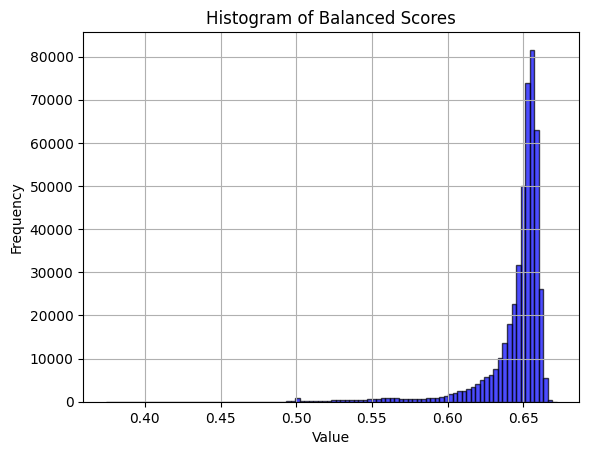

In [53]:
# Plot histogram scores
plt.hist(all_bal_accs[:, -1].numpy(), bins=100, alpha=0.7,
         color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Balanced Scores")
plt.grid(True)

# Show plot
plt.show()

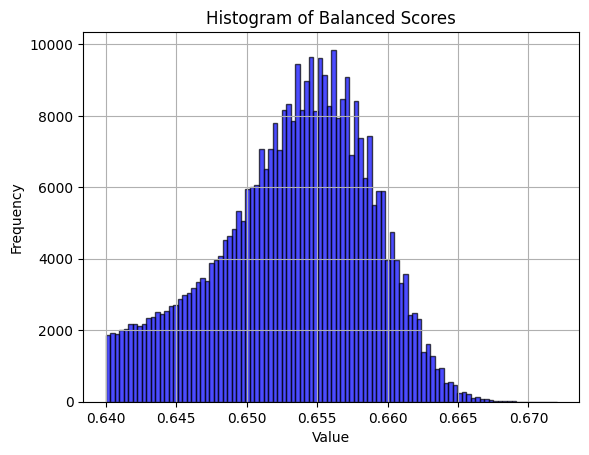

In [54]:
# Plot histogram scores
# idx = (all_bal_accs >= 0.55).all(dim=1)
idx = (all_bal_accs[:, -1] >= 0.64)
filtered_scores = all_bal_accs[idx]
plt.hist(filtered_scores[:, -1].numpy(), bins=100, alpha=0.7,
         color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Balanced Scores")
plt.grid(True)

# Show plot
plt.show()

In [55]:
lower_bound = 0.64

# idx = (all_bal_accs >= lower_bound).all(dim=1)
idx = (all_bal_accs[:, -1] >= lower_bound)

all_labels = all_labels[idx]
all_params = all_params[idx]
all_bal_accs = all_bal_accs[idx]
all_auc_scores = all_auc_scores[idx]

## Black-box attacks

### Weak (balanced accuracies)

In [56]:
attack_name = 'weak'

aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
mlp_bb = joblib.load(
    os.path.join(attack_model_dir,
                 f'mlp_attacker_multilabel_bb_{attack_name}.pkl'))
X_test, y_test = joblib.load(
    os.path.join(attack_model_dir,
                 f'heldout_test_set_bb_{attack_name}.pkl'))

In [57]:
# Predict probabilities and binary labels
y_pred = mlp_bb.predict(X_test)

ham = hamming_loss(y_test, y_pred)
print(f"Accuracy: {1 - ham:.4f}")

# Evaluate using F1-score
print("F1-score:", f1_score(y_test, y_pred, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.7406
F1-score: 0.7673626083959095

Confusion Matrix for Class 0 - Chowell_train:
[[0.75420645 0.24579355]
 [0.0547373  0.9452627 ]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.73787858 0.26212142]
 [0.08213608 0.91786392]]

Confusion Matrix for Class 2 - MSK1:
[[0.68604442 0.31395558]
 [0.17879645 0.82120355]]

Confusion Matrix for Class 3 - MSK2:
[[0.76158468 0.23841532]
 [0.15261195 0.84738805]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.64859383 0.35140617]
 [0.31022074 0.68977926]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.51218441 0.48781559]
 [0.36247318 0.63752682]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.60927282 0.39072718]
 [0.33570562 0.66429438]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.70559761 0.29440239]
 [0.14950114 0.85049886]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.65999842 0.34000158]
 [0.22043596 0.77956404]]


              precision    recall  f1-score   support

           0       0.86      0.95   

### Strong (AUC scores)

In [58]:
attack_name = 'strong'

aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
mlp_bb = joblib.load(
    os.path.join(attack_model_dir,
                 f'mlp_attacker_multilabel_bb_{attack_name}.pkl'))
X_test, y_test = joblib.load(
    os.path.join(attack_model_dir,
                 f'heldout_test_set_bb_{attack_name}.pkl'))

In [59]:
# Predict probabilities and binary labels
y_pred = mlp_bb.predict(X_test)

ham = hamming_loss(y_test, y_pred)
print(f"Accuracy: {1 - ham:.4f}")

# Evaluate using F1-score
print("F1-score:", f1_score(y_test, y_pred, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.7835
F1-score: 0.7957775313486309

Confusion Matrix for Class 0 - Chowell_train:
[[0.98011169 0.01988831]
 [0.01847058 0.98152942]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.9436371  0.0563629 ]
 [0.01296648 0.98703352]]

Confusion Matrix for Class 2 - MSK1:
[[0.69322876 0.30677124]
 [0.10514958 0.89485042]]

Confusion Matrix for Class 3 - MSK2:
[[0.83464567 0.16535433]
 [0.30849722 0.69150278]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.84839099 0.15160901]
 [0.36838713 0.63161287]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.54903952 0.45096048]
 [0.33267167 0.66732833]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.43368174 0.56631826]
 [0.20251463 0.79748537]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.84952016 0.15047984]
 [0.30046875 0.69953125]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.9165765  0.0834235 ]
 [0.33453348 0.66546652]]


              precision    recall  f1-score   support

           0       0.99      0.98   

## White-box attack ensemble

In [60]:
aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name,
                                scaler_type, model_type)
X_test, y_test = joblib.load(os.path.join(attack_model_dir,
                                          'heldout_test_set_wb.pkl'))

# Load models
n_splits = 5
loaded_models = []

# Load each model
for fold in range(1, n_splits + 1):
    model_path = os.path.join(attack_model_dir,
                              f'mlp_attacker_multilabel_wb_fold_{fold}.pkl')
    model = joblib.load(model_path)
    loaded_models.append(model)

In [61]:
# Multilabel: average predictions and apply threshold
all_preds = np.array([model.predict_proba(X_test) for model in loaded_models])
avg_preds = np.mean(all_preds, axis=0)
final_preds = (avg_preds >= 0.5).astype(int)

# Accuracy (or any other metric)
# acc = accuracy_score(y_test, final_preds)
# print(f"Ensemble accuracy: {acc:.4f}")
ham = hamming_loss(y_test, final_preds)
print(f"Ensemble accuracy: {1 - ham:.4f}")

Ensemble accuracy: 0.5370


In [62]:
# Evaluate using F1-score
print("F1-score:", f1_score(y_test, final_preds, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, final_preds)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, final_preds, zero_division=0))

F1-score: 0.6744210449332091

Confusion Matrix for Class 0 - Chowell_train:
[[0. 1.]
 [0. 1.]]

Confusion Matrix for Class 1 - Chowell_test:
[[3.39535515e-05 9.99966046e-01]
 [4.51793621e-05 9.99954821e-01]]

Confusion Matrix for Class 2 - MSK1:
[[1.19738969e-04 9.99880261e-01]
 [2.48052786e-05 9.99975195e-01]]

Confusion Matrix for Class 3 - MSK2:
[[0.00255151 0.99744849]
 [0.00270988 0.99729012]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.00348117 0.99651883]
 [0.00367904 0.99632096]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.00128979 0.99871021]
 [0.00150215 0.99849785]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[4.75099212e-04 9.99524901e-01]
 [6.32611102e-04 9.99367389e-01]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[1.40714266e-04 9.99859286e-01]
 [2.88056145e-04 9.99711944e-01]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[9.99340213e-01 6.59787285e-04]
 [9.99497614e-01 5.02386335e-04]]


              precision    recall  f1-score   support

     

### Evaluate models

In [63]:
def classify_by_dataset(models, params):
    # Multilabel: average predictions and apply threshold
    all_preds = np.array([model.predict_proba(params) for model in models])
    avg_preds = np.mean(all_preds, axis=0)
    
    
    for i in range(len(datasets)):
        print(f'{datasets[i]:>16}: {avg_preds[0][i]:.4f}')

In [64]:
aux_datasets = [0, 4, 5]
cond1 = y_test.sum(dim=1) == len(aux_datasets)
cond2 = y_test[:, aux_datasets].all(dim=1)
aux_params = X_test[cond1 * cond2]

print(aux_params.shape)
idx = torch.randperm(aux_params.shape[0])[0]
aux_coeffs = aux_params[idx].unsqueeze(0)
aux_coeffs

torch.Size([178, 168])


tensor([[ 2.5768e-01, -7.0584e-01, -5.0413e-01,  6.5383e-01,  5.6709e-02,
          5.0624e-01,  2.9223e-01,  9.7227e-01,  4.7646e-02,  4.0356e-01,
          2.2661e-01,  7.5383e-01, -2.2694e+00, -4.7113e+00,  1.8152e+00,
         -1.2321e+00,  1.2916e+00,  9.3122e-01, -5.8306e-01,  4.0782e-01,
          1.6450e+00,  8.9259e-01,  2.7936e-02,  1.2152e-02,  1.0371e+00,
          6.8056e-01,  3.4961e-02,  1.5552e-02, -5.7549e+00, -9.5132e-01,
         -1.3321e-02,  3.8573e-04,  9.4195e+00,  2.0827e+00,  3.3018e-02,
         -4.9556e-04,  4.1528e-01, -6.8761e-02, -2.2857e-02, -6.9633e-03,
         -2.1673e+00, -2.4593e+00, -5.2249e-01,  1.5282e-01, -1.6725e+00,
          1.3322e+00, -2.0156e-02, -2.1391e-03,  1.2828e+00,  3.7885e-01,
         -3.1420e-01,  2.0564e-01,  4.1334e-01, -7.1336e-02, -4.5105e-02,
          5.2461e-02,  2.9144e-01,  2.9074e-01, -6.1761e-02,  6.7974e-02,
          2.1277e-01, -9.5508e-01, -1.9747e-02,  8.3750e-02, -6.4821e-01,
          2.7039e+00, -2.1092e-02,  8.

In [65]:
classify_by_dataset(loaded_models, aux_coeffs)

   Chowell_train: 0.6254
    Chowell_test: 0.5979
            MSK1: 0.5468
            MSK2: 0.5045
      Shim_NSCLC: 0.5004
  Kato_panCancer: 0.5039
   Vanguri_NSCLC: 0.5158
      Ravi_NSCLC: 0.5186
Pradat_panCancer: 0.4872


# TT average

## Datasets

In [66]:
cwd = os.getcwd()

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']
datasets_ids = list(range(1, len(datasets) + 1))

In [68]:
model_name = 'llr6'  # 'llr6' or 'nn2'
og_model = False      # True = llr6, False = tt 
scaler_type = 'standard' # 'standard' or 'minimax'
model_type = 'average' # 'vanilla' or 'average'

aux_dir = 'datasets' if og_model else 'tt_datasets'
dataset_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type,
                           'params_multilabel.pt')

all_labels, all_params, all_bal_accs, all_auc_scores = \
    torch.load(dataset_dir, weights_only=True)

### Accuracies on train/test

In [69]:
cond = (all_labels == torch.tensor([1, 0, 0, 0, 0, 0, 0, 0, 0])).all(dim=1)

In [70]:
all_labels[cond]

tensor([[1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        ...,
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0],
        [1, 0, 0,  ..., 0, 0, 0]], dtype=torch.int32)

In [71]:
all_params[cond][200:300, :][0]

tensor([ 9.2813e-01, -9.4501e-01,  9.0738e-01, -1.8899e-01,  2.8749e-02,
        -2.7890e-02,  5.6894e-02, -5.0047e-02,  1.0291e-01, -1.0297e-01,
         2.6719e-01, -2.3507e-01, -1.2271e+01,  6.0627e+00, -6.5571e+00,
         2.0036e+00, -1.2813e+01,  6.5351e+00, -7.5311e+00,  2.3029e+00,
        -9.2488e+00, -3.2840e+00, -7.5177e-02,  1.4874e-02, -2.6163e+01,
        -1.1164e+01, -2.4325e-01,  4.5140e-02,  2.1902e+00,  1.1985e+00,
        -1.1865e-03, -6.7874e-04, -2.3331e+00, -1.4474e+00, -5.5852e-03,
        -3.0873e-03,  9.6458e-01, -2.3649e-01,  4.7235e-01,  2.4560e-01,
        -1.1372e+00,  7.3299e-01, -8.5660e-01, -4.4429e-01,  1.0364e+00,
        -7.7672e-01,  2.3477e-01, -1.9036e-01, -5.4085e-01,  3.1619e-01,
        -4.7312e-01,  3.8328e-01, -4.0933e+00, -1.3000e+01, -8.0874e-01,
        -1.6813e-02, -3.8277e+00, -1.6027e+01, -9.9910e-01, -2.1955e-02,
         3.4608e+00, -1.1022e+00,  3.3045e-05,  2.6485e-05, -3.4745e-01,
         9.6707e-01, -8.0348e-03,  2.5045e-03, -2.4

In [72]:
# Evaluate on Chowell_test
for iC, C in enumerate([0.1, 1.0, 10.0]):
    for il1, l1 in enumerate([0.0, 0.5, 1.0]):
        i = 3 * iC + il1
        aux = all_auc_scores[cond][(i*100):((i+1)*100), 1]
        if (l1 == 1.0) and (C == 0.1):
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f} <--')
        else:
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f}')

C=0.1 , l1=0.0, mean: 0.7479, std: 0.0011
C=0.1 , l1=0.5, mean: 0.7516, std: 0.0006
C=0.1 , l1=1.0, mean: 0.7535, std: 0.0003 <--
C=1.0 , l1=0.0, mean: 0.7456, std: 0.0008
C=1.0 , l1=0.5, mean: 0.7466, std: 0.0009
C=1.0 , l1=1.0, mean: 0.7475, std: 0.0007
C=10.0, l1=0.0, mean: 0.7435, std: 0.0009
C=10.0, l1=0.5, mean: 0.7442, std: 0.0009
C=10.0, l1=1.0, mean: 0.7442, std: 0.0011


In [73]:
# Evaluate on Chowell_train
for iC, C in enumerate([0.1, 1.0, 10.0]):
    for il1, l1 in enumerate([0.0, 0.5, 1.0]):
        i = 3 * iC + il1
        aux = all_auc_scores[cond][(i*100):((i+1)*100), 0]
        if (l1 == 1.0) and (C == 0.1):
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f} <--')
        else:
            print(f'{C=:<4}, {l1=}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f}')

C=0.1 , l1=0.0, mean: 0.7421, std: 0.0004
C=0.1 , l1=0.5, mean: 0.7421, std: 0.0003
C=0.1 , l1=1.0, mean: 0.7399, std: 0.0003 <--
C=1.0 , l1=0.0, mean: 0.7408, std: 0.0003
C=1.0 , l1=0.5, mean: 0.7412, std: 0.0004
C=1.0 , l1=1.0, mean: 0.7414, std: 0.0003
C=10.0, l1=0.0, mean: 0.7403, std: 0.0003
C=10.0, l1=0.5, mean: 0.7403, std: 0.0003
C=10.0, l1=1.0, mean: 0.7405, std: 0.0003


### Accuracies on all datasets

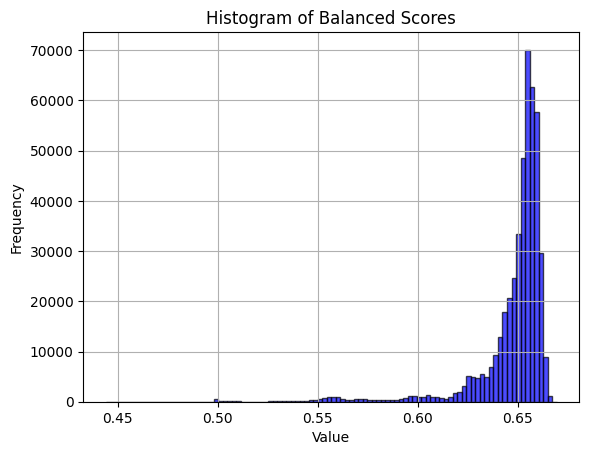

In [74]:
# Plot histogram scores
plt.hist(all_bal_accs[:, -1].numpy(), bins=100, alpha=0.7,
         color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Balanced Scores")
plt.grid(True)

# Show plot
plt.show()

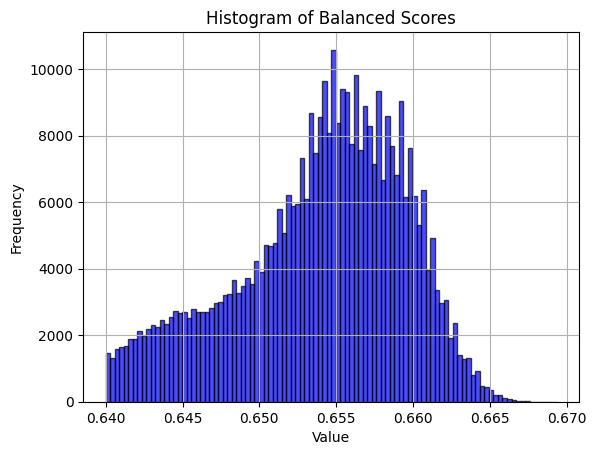

In [75]:
# Plot histogram scores
# idx = (all_bal_accs >= 0.55).all(dim=1)
idx = (all_bal_accs[:, -1] >= 0.64)
filtered_scores = all_bal_accs[idx]
plt.hist(filtered_scores[:, -1].numpy(), bins=100, alpha=0.7,
         color='blue', edgecolor='black')
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Balanced Scores")
plt.grid(True)

# Show plot
plt.show()

In [76]:
lower_bound = 0.64

# idx = (all_bal_accs >= lower_bound).all(dim=1)
idx = (all_bal_accs[:, -1] >= lower_bound)

all_labels = all_labels[idx]
all_params = all_params[idx]
all_bal_accs = all_bal_accs[idx]
all_auc_scores = all_auc_scores[idx]

## Black-box attacks

### Weak (balanced accuracies)

In [77]:
attack_name = 'weak'

aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
mlp_bb = joblib.load(
    os.path.join(attack_model_dir,
                 f'mlp_attacker_multilabel_bb_{attack_name}.pkl'))
X_test, y_test = joblib.load(
    os.path.join(attack_model_dir,
                 f'heldout_test_set_bb_{attack_name}.pkl'))

In [78]:
# Predict probabilities and binary labels
y_pred = mlp_bb.predict(X_test)

ham = hamming_loss(y_test, y_pred)
print(f"Accuracy: {1 - ham:.4f}")

# Evaluate using F1-score
print("F1-score:", f1_score(y_test, y_pred, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.8030
F1-score: 0.8118684230293842

Confusion Matrix for Class 0 - Chowell_train:
[[0.9395113  0.0604887 ]
 [0.05608026 0.94391974]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.83437033 0.16562967]
 [0.02594039 0.97405961]]

Confusion Matrix for Class 2 - MSK1:
[[0.8246455  0.1753545 ]
 [0.19462741 0.80537259]]

Confusion Matrix for Class 3 - MSK2:
[[0.89704954 0.10295046]
 [0.13769467 0.86230533]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.74432412 0.25567588]
 [0.30100091 0.69899909]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.72946962 0.27053038]
 [0.5258184  0.4741816 ]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.46552723 0.53447277]
 [0.14630832 0.85369168]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.91317676 0.08682324]
 [0.1627824  0.8372176 ]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.89276413 0.10723587]
 [0.26247924 0.73752076]]


              precision    recall  f1-score   support

           0       0.96      0.94   

### Strong (AUC scores)

In [79]:
attack_name = 'strong'

aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
mlp_bb = joblib.load(
    os.path.join(attack_model_dir,
                 f'mlp_attacker_multilabel_bb_{attack_name}.pkl'))
X_test, y_test = joblib.load(
    os.path.join(attack_model_dir,
                 f'heldout_test_set_bb_{attack_name}.pkl'))

In [80]:
# Predict probabilities and binary labels
y_pred = mlp_bb.predict(X_test)

ham = hamming_loss(y_test, y_pred)
print(f"Accuracy: {1 - ham:.4f}")

# Evaluate using F1-score
print("F1-score:", f1_score(y_test, y_pred, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.8846
F1-score: 0.892086427114221

Confusion Matrix for Class 0 - Chowell_train:
[[9.98236665e-01 1.76333522e-03]
 [2.61142061e-04 9.99738858e-01]]

Confusion Matrix for Class 1 - Chowell_test:
[[9.97417870e-01 2.58213041e-03]
 [7.90062766e-04 9.99209937e-01]]

Confusion Matrix for Class 2 - MSK1:
[[0.83811236 0.16188764]
 [0.02655821 0.97344179]]

Confusion Matrix for Class 3 - MSK2:
[[0.86885979 0.13114021]
 [0.09777733 0.90222267]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.95770162 0.04229838]
 [0.10149487 0.89850513]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.63065029 0.36934971]
 [0.21148661 0.78851339]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.66741283 0.33258717]
 [0.32631235 0.67368765]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.88917178 0.11082822]
 [0.05579071 0.94420929]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.96285043 0.03714957]
 [0.08696555 0.91303445]]


              precision    recall  f1-score   support

     

## White-box attack ensemble

In [81]:
aux_dir = 'attack_models' if og_model else 'attack_tt_models'
attack_model_dir = os.path.join(cwd, aux_dir, model_name,
                                scaler_type, model_type)
X_test, y_test = joblib.load(os.path.join(attack_model_dir,
                                          'heldout_test_set_wb.pkl'))

# Load models
n_splits = 5
loaded_models = []

# Load each model
for fold in range(1, n_splits + 1):
    model_path = os.path.join(attack_model_dir,
                              f'mlp_attacker_multilabel_wb_fold_{fold}.pkl')
    model = joblib.load(model_path)
    loaded_models.append(model)

In [82]:
# Multilabel: average predictions and apply threshold
all_preds = np.array([model.predict_proba(X_test) for model in loaded_models])
avg_preds = np.mean(all_preds, axis=0)
final_preds = (avg_preds >= 0.5).astype(int)

# Accuracy (or any other metric)
# acc = accuracy_score(y_test, final_preds)
# print(f"Ensemble accuracy: {acc:.4f}")
ham = hamming_loss(y_test, final_preds)
print(f"Ensemble accuracy: {1 - ham:.4f}")

Ensemble accuracy: 0.5303


In [83]:
# Evaluate using F1-score
print("F1-score:", f1_score(y_test, final_preds, average="micro"))
print()

# Compute the confusion matrix for each label separately
conf_matrices = multilabel_confusion_matrix(y_test, final_preds)

# Display confusion matrices per class
for i, cm in enumerate(conf_matrices):
    cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
    cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
    print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
print()

# Generate a detailed classification report
print(classification_report(y_test, final_preds, zero_division=0))

F1-score: 0.6403194600625649

Confusion Matrix for Class 0 - Chowell_train:
[[6.29762580e-05 9.99937024e-01]
 [4.35236769e-05 9.99956476e-01]]

Confusion Matrix for Class 1 - Chowell_test:
[[9.33300149e-05 9.99906670e-01]
 [2.19461879e-05 9.99978054e-01]]

Confusion Matrix for Class 2 - MSK1:
[[6.27692659e-04 9.99372307e-01]
 [1.64084292e-04 9.99835916e-01]]

Confusion Matrix for Class 3 - MSK2:
[[0.00139371 0.99860629]
 [0.00128522 0.99871478]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.99704421 0.00295579]
 [0.99724425 0.00275575]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.00394436 0.99605564]
 [0.00418336 0.99581664]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[1.07974297e-03 9.98920257e-01]
 [9.56263526e-04 9.99043736e-01]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[7.79382729e-04 9.99220617e-01]
 [6.88459381e-04 9.99311541e-01]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.99749783 0.00250217]
 [0.99774284 0.00225716]]


              precision    r

### Evaluate models

In [84]:
def classify_by_dataset(models, params):
    # Multilabel: average predictions and apply threshold
    all_preds = np.array([model.predict_proba(params) for model in models])
    avg_preds = np.mean(all_preds, axis=0)
    
    
    for i in range(len(datasets)):
        print(f'{datasets[i]:>16}: {avg_preds[0][i]:.4f}')

In [85]:
aux_datasets = [0, 4, 5]
cond1 = y_test.sum(dim=1) == len(aux_datasets)
cond2 = y_test[:, aux_datasets].all(dim=1)
aux_params = X_test[cond1 * cond2]

print(aux_params.shape)
idx = torch.randperm(aux_params.shape[0])[0]
aux_coeffs = aux_params[idx].unsqueeze(0)
aux_coeffs

torch.Size([178, 168])


tensor([[ 2.6340e-01,  2.4215e-01, -5.7545e-01,  7.9972e-01,  2.2903e-01,
          8.8114e-01,  6.8059e-01,  2.6022e-01,  1.5080e-01,  6.2786e-01,
          4.8643e-01,  1.8649e-01, -7.6003e-01, -9.7035e-01, -5.3214e-02,
         -8.6947e-02,  2.5868e-01,  3.9880e-02,  2.2625e-01,  3.3909e-01,
         -6.7285e-01, -1.7267e+00, -5.3881e-02, -3.2387e-03,  7.8392e-01,
          1.2001e+00,  3.6746e-02,  1.5840e-03, -2.0753e+00, -1.8122e+00,
          2.0925e-04,  4.7431e-05, -1.1094e-01, -3.1273e-01,  1.5783e-02,
          1.3991e-02, -1.5536e+00, -6.9206e-01, -2.7923e-01, -2.3164e+00,
          1.8603e+00,  1.6392e+00,  3.0605e-01,  2.5786e+00,  2.2538e+00,
         -1.7009e+00,  5.2531e-01,  1.7316e+00,  3.2270e-04,  1.1376e+00,
         -9.7165e-02, -2.7499e-01, -8.6615e-01, -6.4047e-01,  3.0533e-02,
         -3.2790e-01,  3.3995e-01, -7.1282e-01, -3.5741e-03,  1.1577e-01,
          2.2320e-01, -8.8045e-01,  1.4888e-01, -1.3924e-03,  1.9643e+00,
         -8.6633e-02,  1.6160e-02,  1.

In [86]:
classify_by_dataset(loaded_models, aux_coeffs)

   Chowell_train: 0.5926
    Chowell_test: 0.5869
            MSK1: 0.5455
            MSK2: 0.5119
      Shim_NSCLC: 0.4976
  Kato_panCancer: 0.5080
   Vanguri_NSCLC: 0.5119
      Ravi_NSCLC: 0.5085
Pradat_panCancer: 0.4966


# LLR6 DP vanilla

## Datasets

In [2]:
cwd = os.getcwd()

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']
datasets_ids = list(range(1, len(datasets) + 1))
epsilon_list = [0.01, 0.1, 1.0, 10.0, 100.0, float('inf')]

In [3]:
model_name = 'llr6'  # 'llr6' or 'nn2'
scaler_type = 'standard' # 'standard' or 'minimax'
model_type = 'vanilla' # 'vanilla' or 'average'

aux_dir = 'dp_datasets'

all_labels = {}
all_params = {}
all_bal_accs = {}
all_auc_scores = {}

for epsilon in epsilon_list:
    dataset_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type,
                               f'params_multilabel_{epsilon}.pt')

    all_labels_eps, all_params_eps, all_bal_accs_eps, all_auc_scores_eps = \
        torch.load(dataset_dir, weights_only=True)
    
    all_labels[epsilon] = all_labels_eps
    all_params[epsilon] = all_params_eps
    all_bal_accs[epsilon] = all_bal_accs_eps
    all_auc_scores[epsilon] = all_auc_scores_eps

### Accuracies on train/test

In [31]:
# Evaluate on Chowell_test
for eps in epsilon_list:
    cond = (all_labels[eps] == torch.tensor([1, 0, 0, 0, 0, 0, 0, 0, 0])).all(dim=1)
    aux = all_auc_scores[eps][cond][:, 1]
    display(Latex(fr'$\epsilon$={eps:<6}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f}'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [32]:
# Evaluate on Chowell_train
for eps in epsilon_list:
    cond = (all_labels[eps] == torch.tensor([1, 0, 0, 0, 0, 0, 0, 0, 0])).all(dim=1)
    aux = all_auc_scores[eps][cond][:, 0]
    display(Latex(fr'$\epsilon$={eps:<6}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f}'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Accuracies on all datasets

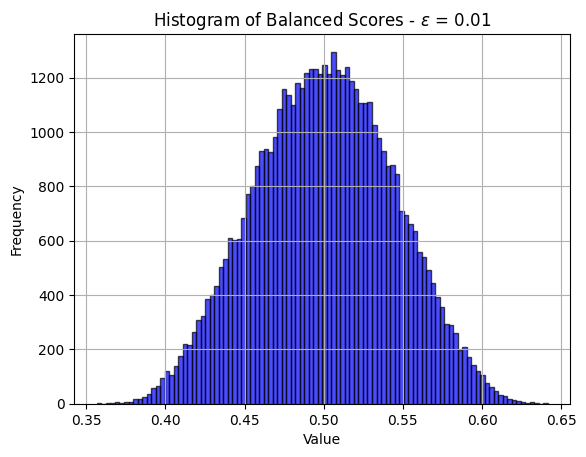

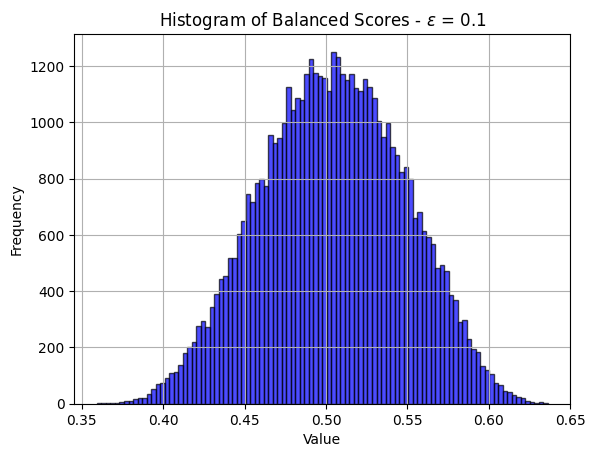

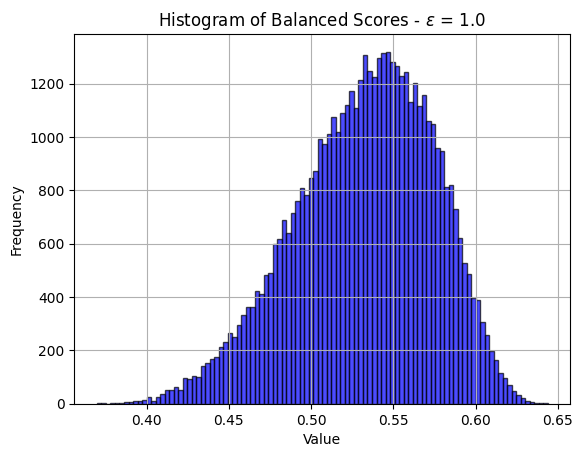

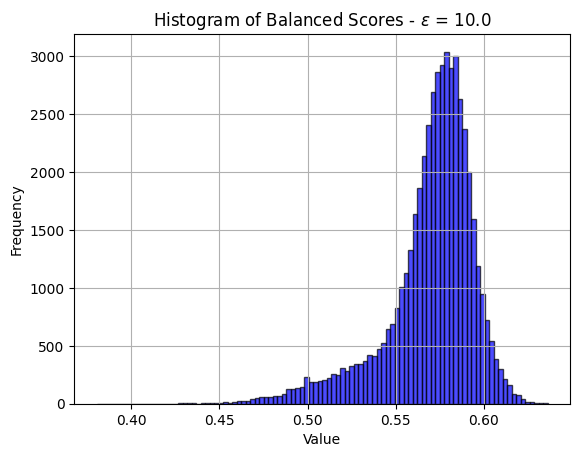

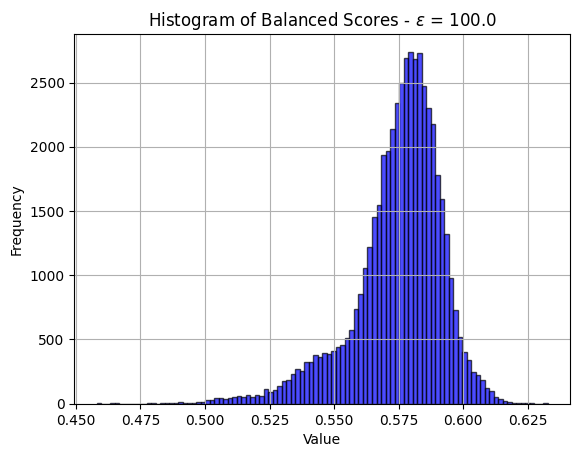

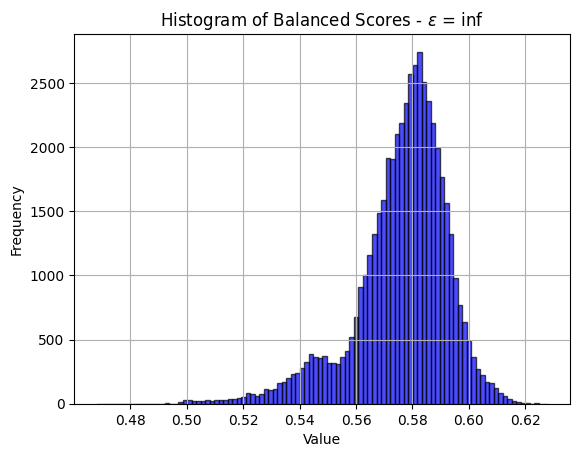

In [36]:
# Plot histogram scores
for eps in epsilon_list:
    plt.hist(all_bal_accs[eps][:, -1].numpy(), bins=100, alpha=0.7,
             color='blue', edgecolor='black')
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.title(f"Histogram of Balanced Scores - $\epsilon$ = {eps}")
    plt.grid(True)

    # Show plot
    plt.show()

## Black-box attacks

### Weak (balanced accuracies)

In [37]:
attack_name = 'weak'

for eps in epsilon_list:
    display(Latex(f'Weak black-box attack - $\epsilon$={eps}'))
    aux_dir = 'attack_dp_models'
    attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
    mlp_bb = joblib.load(
        os.path.join(attack_model_dir,
                     f'mlp_attacker_multilabel_bb_{attack_name}_{eps}.pkl'))
    X_test, y_test = joblib.load(
        os.path.join(attack_model_dir,
                     f'heldout_test_set_bb_{attack_name}_{eps}.pkl'))
    
    # Predict probabilities and binary labels
    y_pred = mlp_bb.predict(X_test)

    ham = hamming_loss(y_test, y_pred)
    print(f"Accuracy: {1 - ham:.4f}")

    # Evaluate using F1-score
    print("F1-score:", f1_score(y_test, y_pred, average="micro"))
    print()

    # Compute the confusion matrix for each label separately
    conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

    # Display confusion matrices per class
    for i, cm in enumerate(conf_matrices):
        cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
        cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
        print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
    print()

    # Generate a detailed classification report
    print(classification_report(y_test, y_pred, zero_division=0))

<IPython.core.display.Latex object>

Accuracy: 0.5109
F1-score: 0.49508929072521357

Confusion Matrix for Class 0 - Chowell_train:
[[0.66927746 0.33072254]
 [0.61294739 0.38705261]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.7127451 0.2872549]
 [0.715625  0.284375 ]]

Confusion Matrix for Class 2 - MSK1:
[[0.50313725 0.49686275]
 [0.45878906 0.54121094]]

Confusion Matrix for Class 3 - MSK2:
[[0.13797788 0.86202212]
 [0.13558319 0.86441681]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.74621882 0.25378118]
 [0.74166504 0.25833496]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.82198234 0.17801766]
 [0.81365854 0.18634146]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.40496356 0.59503644]
 [0.36710091 0.63289909]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.26237527 0.73762473]
 [0.22156978 0.77843022]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.62359985 0.37640015]
 [0.61205871 0.38794129]]


              precision    recall  f1-score   support

           0       0.54      0.39      

<IPython.core.display.Latex object>

Accuracy: 0.5137
F1-score: 0.5593838031637216

Confusion Matrix for Class 0 - Chowell_train:
[[0.38887801 0.61112199]
 [0.33189908 0.66810092]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.35627451 0.64372549]
 [0.32636719 0.67363281]]

Confusion Matrix for Class 2 - MSK1:
[[0.50568627 0.49431373]
 [0.47402344 0.52597656]]

Confusion Matrix for Class 3 - MSK2:
[[0.28119542 0.71880458]
 [0.27333728 0.72666272]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.50775879 0.49224121]
 [0.48372002 0.51627998]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.35603533 0.64396467]
 [0.35902439 0.64097561]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.48926531 0.51073469]
 [0.45537624 0.54462376]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.40090002 0.59909998]
 [0.34077119 0.65922881]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.40305137 0.59694863]
 [0.39428798 0.60571202]]


              precision    recall  f1-score   support

           0       0.52      0.67   

<IPython.core.display.Latex object>

...

Accuracy: 0.6892
F1-score: 0.6941457203086043

Confusion Matrix for Class 0 - Chowell_train:
[[0.78421774 0.21578226]
 [0.09602973 0.90397027]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.75686275 0.24313725]
 [0.1796875  0.8203125 ]]

Confusion Matrix for Class 2 - MSK1:
[[0.69901961 0.30098039]
 [0.23691406 0.76308594]]

Confusion Matrix for Class 3 - MSK2:
[[0.73316515 0.26683485]
 [0.27156108 0.72843892]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.63072088 0.36927912]
 [0.48800936 0.51199064]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.58724239 0.41275761]
 [0.53092683 0.46907317]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.59976364 0.40023636]
 [0.33754618 0.66245382]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.70475445 0.29524555]
 [0.15521628 0.84478372]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.5608343  0.4391657 ]
 [0.35303451 0.64696549]]


              precision    recall  f1-score   support

           0       0.81      0.90   

<IPython.core.display.Latex object>

Accuracy: 0.7562
F1-score: 0.76619653709437

Confusion Matrix for Class 0 - Chowell_train:
[[0.9594674  0.0405326 ]
 [0.06395463 0.93604537]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.90235294 0.09764706]
 [0.16171875 0.83828125]]

Confusion Matrix for Class 2 - MSK1:
[[0.82823529 0.17176471]
 [0.07070312 0.92929687]]

Confusion Matrix for Class 3 - MSK2:
[[0.47486901 0.52513099]
 [0.32366292 0.67633708]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.46356315 0.53643685]
 [0.22713979 0.77286021]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.43081452 0.56918548]
 [0.29307317 0.70692683]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.59740004 0.40259996]
 [0.20532763 0.79467237]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.90921542 0.09078458]
 [0.03366608 0.96633392]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.84820394 0.15179606]
 [0.4293931  0.5706069 ]]


              precision    recall  f1-score   support

           0       0.96      0.94     

<IPython.core.display.Latex object>

Accuracy: 0.7442
F1-score: 0.739755118293128

Confusion Matrix for Class 0 - Chowell_train:
[[0.92637556 0.07362444]
 [0.03931156 0.96068844]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.9345098  0.0654902 ]
 [0.17246094 0.82753906]]

Confusion Matrix for Class 2 - MSK1:
[[0.86686275 0.13313725]
 [0.12929687 0.87070312]]

Confusion Matrix for Class 3 - MSK2:
[[0.62526683 0.37473317]
 [0.42569568 0.57430432]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.59870359 0.40129641]
 [0.42210957 0.57789043]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.63159961 0.36840039]
 [0.51258537 0.48741463]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.57533977 0.42466023]
 [0.30157496 0.69842504]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.93954216 0.06045784]
 [0.07888041 0.92111959]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.74951719 0.25048281]
 [0.37247124 0.62752876]]


              precision    recall  f1-score   support

           0       0.93      0.96    

### Strong (AUC scores)

In [38]:
attack_name = 'strong'

for eps in epsilon_list:
    display(Latex(f'Strong black-box attack - $\epsilon$={eps}'))
    aux_dir = 'attack_dp_models'
    attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
    mlp_bb = joblib.load(
        os.path.join(attack_model_dir,
                     f'mlp_attacker_multilabel_bb_{attack_name}_{eps}.pkl'))
    X_test, y_test = joblib.load(
        os.path.join(attack_model_dir,
                     f'heldout_test_set_bb_{attack_name}_{eps}.pkl'))
    
    # Predict probabilities and binary labels
    y_pred = mlp_bb.predict(X_test)

    ham = hamming_loss(y_test, y_pred)
    print(f"Accuracy: {1 - ham:.4f}")

    # Evaluate using F1-score
    print("F1-score:", f1_score(y_test, y_pred, average="micro"))
    print()

    # Compute the confusion matrix for each label separately
    conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

    # Display confusion matrices per class
    for i, cm in enumerate(conf_matrices):
        cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
        cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
        print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
    print()

    # Generate a detailed classification report
    print(classification_report(y_test, y_pred, zero_division=0))

<IPython.core.display.Latex object>

Accuracy: 0.5161
F1-score: 0.5750023870906139

Confusion Matrix for Class 0 - Chowell_train:
[[0.17035442 0.82964558]
 [0.11930374 0.88069626]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.2945098  0.7054902 ]
 [0.26992187 0.73007812]]

Confusion Matrix for Class 2 - MSK1:
[[0.32803922 0.67196078]
 [0.25742187 0.74257812]]

Confusion Matrix for Class 3 - MSK2:
[[0.60450223 0.39549777]
 [0.60706532 0.39293468]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.42231389 0.57768611]
 [0.40417235 0.59582765]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.23473994 0.76526006]
 [0.23063415 0.76936585]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.28678353 0.71321647]
 [0.24518763 0.75481237]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.69516729 0.30483271]
 [0.65061656 0.34938344]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.35631518 0.64368482]
 [0.32368108 0.67631892]]


              precision    recall  f1-score   support

           0       0.52      0.88   

<IPython.core.display.Latex object>

Accuracy: 0.5171
F1-score: 0.5461160335612308

Confusion Matrix for Class 0 - Chowell_train:
[[0.26375563 0.73624437]
 [0.19753569 0.80246431]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.22568627 0.77431373]
 [0.18085937 0.81914062]]

Confusion Matrix for Class 2 - MSK1:
[[0.72843137 0.27156863]
 [0.69707031 0.30292969]]

Confusion Matrix for Class 3 - MSK2:
[[0.23209781 0.76790219]
 [0.22281429 0.77718571]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.49420546 0.50579454]
 [0.4677325  0.5322675 ]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.39313052 0.60686948]
 [0.38341463 0.61658537]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.52767382 0.47232618]
 [0.49640288 0.50359712]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.52866367 0.47133633]
 [0.47798004 0.52201996]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.68346852 0.31653148]
 [0.64577549 0.35422451]]


              precision    recall  f1-score   support

           0       0.52      0.80   

<IPython.core.display.Latex object>

...

Accuracy: 0.6925
F1-score: 0.694461850947514

Confusion Matrix for Class 0 - Chowell_train:
[[0.95574701 0.04425299]
 [0.02307843 0.97692157]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.87784314 0.12215686]
 [0.09570312 0.90429687]]

Confusion Matrix for Class 2 - MSK1:
[[0.61098039 0.38901961]
 [0.15019531 0.84980469]]

Confusion Matrix for Class 3 - MSK2:
[[0.70327964 0.29672036]
 [0.47148214 0.52851786]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.61461402 0.38538598]
 [0.4154806  0.5845194 ]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.47733072 0.52266928]
 [0.33034146 0.66965854]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.69745913 0.30254087]
 [0.54890142 0.45109858]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.64292702 0.35707298]
 [0.32374242 0.67625758]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.59385863 0.40614137]
 [0.3494645  0.6505355 ]]


              precision    recall  f1-score   support

           0       0.96      0.98    

<IPython.core.display.Latex object>

Accuracy: 0.7755
F1-score: 0.783996149701288

Confusion Matrix for Class 0 - Chowell_train:
[[0.98002741 0.01997259]
 [0.00352044 0.99647956]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.98529412 0.01470588]
 [0.10332031 0.89667969]]

Confusion Matrix for Class 2 - MSK1:
[[0.95588235 0.04411765]
 [0.16425781 0.83574219]]

Confusion Matrix for Class 3 - MSK2:
[[0.50902387 0.49097613]
 [0.15867377 0.84132623]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.74445099 0.25554901]
 [0.2858257  0.7141743 ]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.60628067 0.39371933]
 [0.30653659 0.69346341]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.48591688 0.51408312]
 [0.28776978 0.71223022]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.65016631 0.34983369]
 [0.15697788 0.84302212]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.70915411 0.29084589]
 [0.19654899 0.80345101]]


              precision    recall  f1-score   support

           0       0.98      1.00    

<IPython.core.display.Latex object>

Accuracy: 0.7760
F1-score: 0.7778783763392183

Confusion Matrix for Class 0 - Chowell_train:
[[0.98002741 0.01997259]
 [0.0088011  0.9911989 ]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.96588235 0.03411765]
 [0.034375   0.965625  ]]

Confusion Matrix for Class 2 - MSK1:
[[0.87882353 0.12117647]
 [0.04140625 0.95859375]]

Confusion Matrix for Class 3 - MSK2:
[[0.56394333 0.43605667]
 [0.28971778 0.71028222]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.78196818 0.21803182]
 [0.32501462 0.67498538]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.59941119 0.40058881]
 [0.31160976 0.68839024]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.62261178 0.37738822]
 [0.43982112 0.56017888]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.73918998 0.26081002]
 [0.2501468  0.7498532 ]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.77134029 0.22865971]
 [0.23363745 0.76636255]]


              precision    recall  f1-score   support

           0       0.98      0.99   

## White-box attack ensemble

In [39]:
attack_name = 'weak'

for eps in epsilon_list:
    display(Latex(f'Weak black-box attack - $\epsilon$={eps}'))
    aux_dir = 'attack_dp_models'
    attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
    
    X_test, y_test = joblib.load(os.path.join(attack_model_dir,
                                              f'heldout_test_set_wb_{eps}.pkl'))

    # Load models
    n_splits = 5
    loaded_models = []

    # Load each model
    for fold in range(1, n_splits + 1):
        model_path = os.path.join(attack_model_dir,
                                  f'mlp_attacker_multilabel_wb_fold_{fold}_{eps}.pkl')
        model = joblib.load(model_path)
        loaded_models.append(model)
    
    # Multilabel: average predictions and apply threshold
    all_preds = np.array([model.predict_proba(X_test) for model in loaded_models])
    avg_preds = np.mean(all_preds, axis=0)
    final_preds = (avg_preds >= 0.5).astype(int)

    # Accuracy (or any other metric)
    # acc = accuracy_score(y_test, final_preds)
    # print(f"Ensemble accuracy: {acc:.4f}")
    ham = hamming_loss(y_test, final_preds)
    print(f"Ensemble accuracy: {1 - ham:.4f}")

    # Evaluate using F1-score
    print("F1-score:", f1_score(y_test, final_preds, average="micro"))
    print()

    # Compute the confusion matrix for each label separately
    conf_matrices = multilabel_confusion_matrix(y_test, final_preds)

    # Display confusion matrices per class
    for i, cm in enumerate(conf_matrices):
        cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
        cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
        print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
    print()

    # Generate a detailed classification report
    print(classification_report(y_test, final_preds, zero_division=0))

<IPython.core.display.Latex object>

Ensemble accuracy: 0.5147
F1-score: 0.6710687281677893

Confusion Matrix for Class 0 - Chowell_train:
[[0.0667711  0.9332289 ]
 [0.00958341 0.99041659]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.06196078 0.93803922]
 [0.01015625 0.98984375]]

Confusion Matrix for Class 2 - MSK1:
[[0.0645098  0.9354902 ]
 [0.00644531 0.99355469]]

Confusion Matrix for Class 3 - MSK2:
[[0.00815059 0.99184941]
 [0.00868364 0.99131636]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.0102141  0.9897859 ]
 [0.01150322 0.98849678]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.05986261 0.94013739]
 [0.01014634 0.98985366]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.01201497 0.98798503]
 [0.0114719  0.9885281 ]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.01095676 0.98904324]
 [0.01291838 0.98708162]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.06064117 0.93935883]
 [0.00476002 0.99523998]]


              precision    recall  f1-score   support

           0       0.52    

<IPython.core.display.Latex object>

Ensemble accuracy: 0.5602
F1-score: 0.6242510380960343

Confusion Matrix for Class 0 - Chowell_train:
[[0.48874094 0.51125906]
 [0.07471152 0.92528848]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.50117647 0.49882353]
 [0.06914062 0.93085937]]

Confusion Matrix for Class 2 - MSK1:
[[0.06470588 0.93529412]
 [0.00507812 0.99492187]]

Confusion Matrix for Class 3 - MSK2:
[[0.01086746 0.98913254]
 [0.01124926 0.98875074]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.78923591 0.21076409]
 [0.76272178 0.23727822]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.06241413 0.93758587]
 [0.0097561  0.9902439 ]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.78707898 0.21292102]
 [0.75714563 0.24285437]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.75171199 0.24828801]
 [0.71364259 0.28635741]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.0616068 0.9383932]
 [0.0093217 0.9906783]]


              precision    recall  f1-score   support

           0       0.64      0.

<IPython.core.display.Latex object>

...

Ensemble accuracy: 0.6979
F1-score: 0.701560670669488

Confusion Matrix for Class 0 - Chowell_train:
[[0.94928529 0.05071471]
 [0.03735576 0.96264424]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.86823529 0.13176471]
 [0.09433594 0.90566406]]

Confusion Matrix for Class 2 - MSK1:
[[0.70470588 0.29529412]
 [0.11757812 0.88242187]]

Confusion Matrix for Class 3 - MSK2:
[[0.83252474 0.16747526]
 [0.2541938  0.7458062 ]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.55961501 0.44038499]
 [0.41002145 0.58997855]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.4889107 0.5110893]
 [0.3795122 0.6204878]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.53082529 0.46917471]
 [0.43146024 0.56853976]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.60105654 0.39894346]
 [0.53141515 0.46858485]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.63151796 0.36848204]
 [0.34986117 0.65013883]]


              precision    recall  f1-score   support

           0       0.95      0.9

<IPython.core.display.Latex object>

Ensemble accuracy: 0.8992
F1-score: 0.9006874986614123

Confusion Matrix for Class 0 - Chowell_train:
[[0.99862933 0.00137067]
 [0.00117348 0.99882652]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.99019608 0.00980392]
 [0.00859375 0.99140625]]

Confusion Matrix for Class 2 - MSK1:
[[0.97647059 0.02352941]
 [0.015625   0.984375  ]]

Confusion Matrix for Class 3 - MSK2:
[[0.85484184 0.14515816]
 [0.02861654 0.97138346]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.80828914 0.19171086]
 [0.15188146 0.84811854]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.74052993 0.25947007]
 [0.22536585 0.77463415]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.71676187 0.28323813]
 [0.18646704 0.81353296]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.91801996 0.08198004]
 [0.07848894 0.92151106]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.94592507 0.05407493]
 [0.06842523 0.93157477]]


              precision    recall  f1-score   support

           0       1.00    

<IPython.core.display.Latex object>

Ensemble accuracy: 0.9333
F1-score: 0.9333652038809636

Confusion Matrix for Class 0 - Chowell_train:
[[9.99216761e-01 7.83238692e-04]
 [3.91159789e-04 9.99608840e-01]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.99392157 0.00607843]
 [0.00390625 0.99609375]]

Confusion Matrix for Class 2 - MSK1:
[[0.99529412 0.00470588]
 [0.0078125  0.9921875 ]]

Confusion Matrix for Class 3 - MSK2:
[[0.9974772  0.0025228 ]
 [0.00335504 0.99664496]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.86368101 0.13631899]
 [0.1399883  0.8600117 ]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.80510304 0.19489696]
 [0.19746341 0.80253659]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.80854836 0.19145164]
 [0.14369045 0.85630955]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.95930346 0.04069654]
 [0.04247407 0.95752593]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.96543067 0.03456933]
 [0.0495835  0.9504165 ]]


              precision    recall  f1-score   support

           

# LLR6 DP average

## Datasets

In [40]:
cwd = os.getcwd()

datasets = ['Chowell_train', 'Chowell_test', 'MSK1', 'MSK2', 'Shim_NSCLC',
            'Kato_panCancer', 'Vanguri_NSCLC', 'Ravi_NSCLC', 'Pradat_panCancer']
datasets_ids = list(range(1, len(datasets) + 1))
epsilon_list = [0.01, 0.1, 1.0, 10.0, 100.0, float('inf')]

In [41]:
model_name = 'llr6'  # 'llr6' or 'nn2'
scaler_type = 'standard' # 'standard' or 'minimax'
model_type = 'average' # 'vanilla' or 'average'

aux_dir = 'dp_datasets'

all_labels = {}
all_params = {}
all_bal_accs = {}
all_auc_scores = {}

for epsilon in epsilon_list:
    dataset_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type,
                               f'params_multilabel_{epsilon}.pt')

    all_labels_eps, all_params_eps, all_bal_accs_eps, all_auc_scores_eps = \
        torch.load(dataset_dir, weights_only=True)
    
    all_labels[epsilon] = all_labels_eps
    all_params[epsilon] = all_params_eps
    all_bal_accs[epsilon] = all_bal_accs_eps
    all_auc_scores[epsilon] = all_auc_scores_eps

### Accuracies on train/test

In [42]:
# Evaluate on Chowell_test
for eps in epsilon_list:
    cond = (all_labels[eps] == torch.tensor([1, 0, 0, 0, 0, 0, 0, 0, 0])).all(dim=1)
    aux = all_auc_scores[eps][cond][:, 1]
    display(Latex(fr'$\epsilon$={eps:<6}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f}'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [43]:
# Evaluate on Chowell_train
for eps in epsilon_list:
    cond = (all_labels[eps] == torch.tensor([1, 0, 0, 0, 0, 0, 0, 0, 0])).all(dim=1)
    aux = all_auc_scores[eps][cond][:, 0]
    display(Latex(fr'$\epsilon$={eps:<6}, mean: {aux.mean().item():.4f}, '
                  f'std: {aux.std().item():.4f}'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

### Accuracies on all datasets

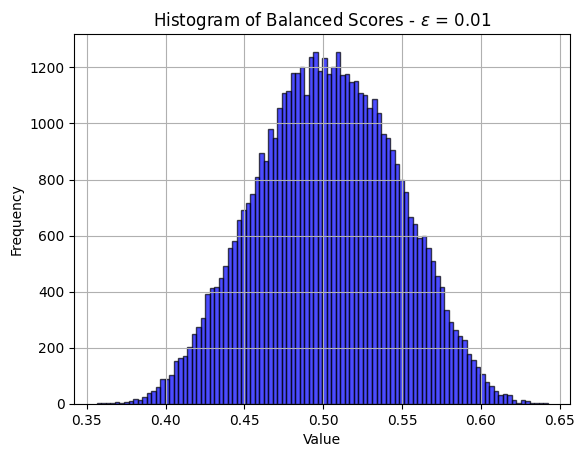

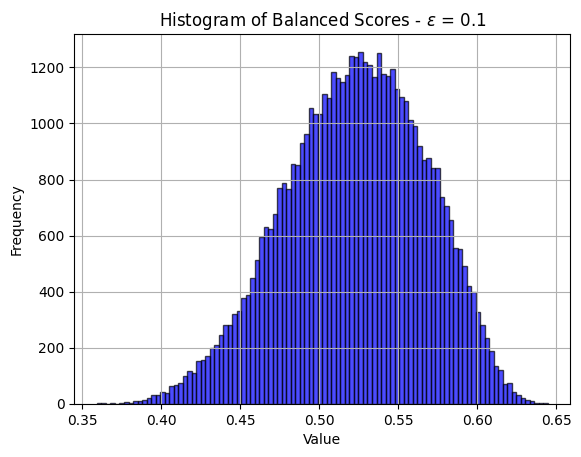

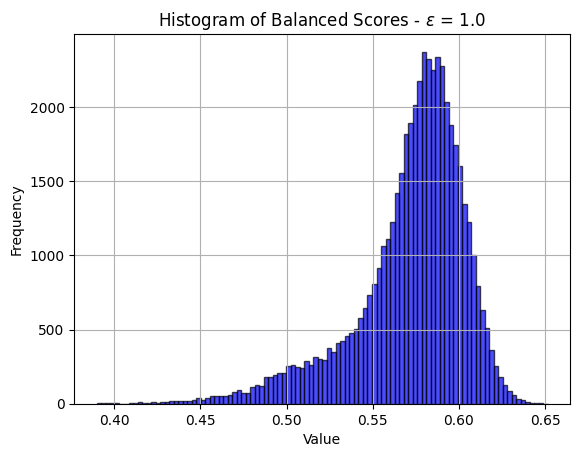

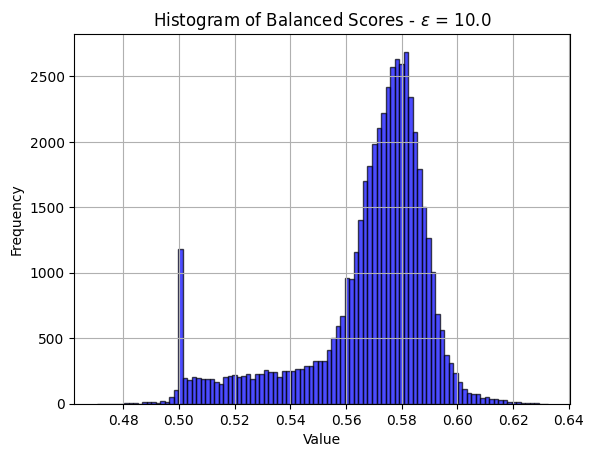

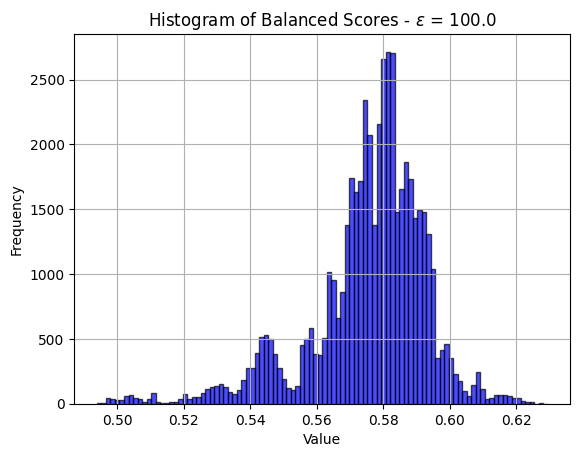

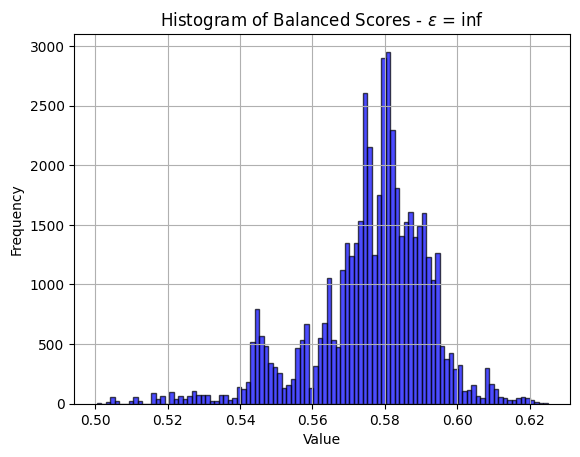

In [44]:
# Plot histogram scores
for eps in epsilon_list:
    plt.hist(all_bal_accs[eps][:, -1].numpy(), bins=100, alpha=0.7,
             color='blue', edgecolor='black')
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.title(f"Histogram of Balanced Scores - $\epsilon$ = {eps}")
    plt.grid(True)

    # Show plot
    plt.show()

## Black-box attacks

### Weak (balanced accuracies)

In [45]:
attack_name = 'weak'

for eps in epsilon_list:
    display(Latex(f'Weak black-box attack - $\epsilon$={eps}'))
    aux_dir = 'attack_dp_models'
    attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
    mlp_bb = joblib.load(
        os.path.join(attack_model_dir,
                     f'mlp_attacker_multilabel_bb_{attack_name}_{eps}.pkl'))
    X_test, y_test = joblib.load(
        os.path.join(attack_model_dir,
                     f'heldout_test_set_bb_{attack_name}_{eps}.pkl'))
    
    # Predict probabilities and binary labels
    y_pred = mlp_bb.predict(X_test)

    ham = hamming_loss(y_test, y_pred)
    print(f"Accuracy: {1 - ham:.4f}")

    # Evaluate using F1-score
    print("F1-score:", f1_score(y_test, y_pred, average="micro"))
    print()

    # Compute the confusion matrix for each label separately
    conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

    # Display confusion matrices per class
    for i, cm in enumerate(conf_matrices):
        cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
        cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
        print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
    print()

    # Generate a detailed classification report
    print(classification_report(y_test, y_pred, zero_division=0))

<IPython.core.display.Latex object>

Accuracy: 0.5092
F1-score: 0.5631163803532543

Confusion Matrix for Class 0 - Chowell_train:
[[0.42196985 0.57803015]
 [0.38666145 0.61333855]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.29137255 0.70862745]
 [0.27246094 0.72753906]]

Confusion Matrix for Class 2 - MSK1:
[[0.32039216 0.67960784]
 [0.30917969 0.69082031]]

Confusion Matrix for Class 3 - MSK2:
[[0.08169998 0.91830002]
 [0.09334912 0.90665088]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.42938519 0.57061481]
 [0.41567557 0.58432443]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.70343474 0.29656526]
 [0.69717073 0.30282927]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.38428206 0.61571794]
 [0.34260159 0.65739841]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.63333986 0.36666014]
 [0.59209239 0.40790761]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.21108536 0.78891464]
 [0.1896073  0.8103927 ]]


              precision    recall  f1-score   support

           0       0.52      0.61   

<IPython.core.display.Latex object>

Accuracy: 0.5326
F1-score: 0.5432371563336591

Confusion Matrix for Class 0 - Chowell_train:
[[0.56177795 0.43822205]
 [0.31762175 0.68237825]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.44509804 0.55490196]
 [0.32773437 0.67226562]]

Confusion Matrix for Class 2 - MSK1:
[[0.53196078 0.46803922]
 [0.47558594 0.52441406]]

Confusion Matrix for Class 3 - MSK2:
[[0.20201824 0.79798176]
 [0.18807973 0.81192027]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.58141819 0.41858181]
 [0.53597192 0.46402808]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.52482826 0.47517174]
 [0.50809756 0.49190244]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.51999212 0.48000788]
 [0.49756951 0.50243049]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.64136177 0.35863823]
 [0.56566843 0.43433157]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.57377366 0.42622634]
 [0.57675526 0.42324474]]


              precision    recall  f1-score   support

           0       0.61      0.68   

<IPython.core.display.Latex object>

...

Accuracy: 0.7512
F1-score: 0.7656341201167375

Confusion Matrix for Class 0 - Chowell_train:
[[0.96827883 0.03172117]
 [0.01036573 0.98963427]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.88294118 0.11705882]
 [0.09765625 0.90234375]]

Confusion Matrix for Class 2 - MSK1:
[[0.71803922 0.28196078]
 [0.07988281 0.92011719]]

Confusion Matrix for Class 3 - MSK2:
[[0.30098971 0.69901029]
 [0.05683837 0.94316163]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.48281281 0.51718719]
 [0.3341782  0.6658218 ]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.56113837 0.43886163]
 [0.49014634 0.50985366]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.55938546 0.44061454]
 [0.25160412 0.74839588]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.92819409 0.07180591]
 [0.03562341 0.96437659]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.80088837 0.19911163]
 [0.32368108 0.67631892]]


              precision    recall  f1-score   support

           0       0.97      0.99   

<IPython.core.display.Latex object>

Accuracy: 0.7839
F1-score: 0.7876904014185306

Confusion Matrix for Class 0 - Chowell_train:
[[9.99608381e-01 3.91619346e-04]
 [1.13436339e-02 9.88656366e-01]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.87215686 0.12784314]
 [0.09375    0.90625   ]]

Confusion Matrix for Class 2 - MSK1:
[[0.92588235 0.07411765]
 [0.03261719 0.96738281]]

Confusion Matrix for Class 3 - MSK2:
[[0.59247041 0.40752959]
 [0.32405763 0.67594237]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.56000786 0.43999214]
 [0.35523494 0.64476506]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.48498528 0.51501472]
 [0.41287805 0.58712195]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.64703565 0.35296435]
 [0.22146607 0.77853393]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.98826061 0.01173939]
 [0.01350558 0.98649442]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.82020085 0.17979915]
 [0.31812773 0.68187227]]


              precision    recall  f1-score   support

           0       1

<IPython.core.display.Latex object>

Accuracy: 0.7908
F1-score: 0.7993493425648832

Confusion Matrix for Class 0 - Chowell_train:
[[0.99784609 0.00215391]
 [0.0369646  0.9630354 ]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.82313725 0.17686275]
 [0.03457031 0.96542969]]

Confusion Matrix for Class 2 - MSK1:
[[0.95352941 0.04647059]
 [0.03945312 0.96054687]]

Confusion Matrix for Class 3 - MSK2:
[[0.39122841 0.60877159]
 [0.26327215 0.73672785]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.47043803 0.52956197]
 [0.12029635 0.87970365]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.68714426 0.31285574]
 [0.62204878 0.37795122]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.68170179 0.31829821]
 [0.14777367 0.85222633]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.99315203 0.00684797]
 [0.01546291 0.98453709]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.73406721 0.26593279]
 [0.21658072 0.78341928]]


              precision    recall  f1-score   support

           0       1.00      0.96   

### Strong (AUC scores)

In [46]:
attack_name = 'strong'

for eps in epsilon_list:
    display(Latex(f'Strong black-box attack - $\epsilon$={eps}'))
    aux_dir = 'attack_dp_models'
    attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
    mlp_bb = joblib.load(
        os.path.join(attack_model_dir,
                     f'mlp_attacker_multilabel_bb_{attack_name}_{eps}.pkl'))
    X_test, y_test = joblib.load(
        os.path.join(attack_model_dir,
                     f'heldout_test_set_bb_{attack_name}_{eps}.pkl'))
    
    # Predict probabilities and binary labels
    y_pred = mlp_bb.predict(X_test)

    ham = hamming_loss(y_test, y_pred)
    print(f"Accuracy: {1 - ham:.4f}")

    # Evaluate using F1-score
    print("F1-score:", f1_score(y_test, y_pred, average="micro"))
    print()

    # Compute the confusion matrix for each label separately
    conf_matrices = multilabel_confusion_matrix(y_test, y_pred)

    # Display confusion matrices per class
    for i, cm in enumerate(conf_matrices):
        cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
        cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
        print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
    print()

    # Generate a detailed classification report
    print(classification_report(y_test, y_pred, zero_division=0))

<IPython.core.display.Latex object>

Accuracy: 0.5181
F1-score: 0.5492138396761792

Confusion Matrix for Class 0 - Chowell_train:
[[0.38006658 0.61993342]
 [0.33541952 0.66458048]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.46078431 0.53921569]
 [0.40605469 0.59394531]]

Confusion Matrix for Class 2 - MSK1:
[[0.54490196 0.45509804]
 [0.46914062 0.53085937]]

Confusion Matrix for Class 3 - MSK2:
[[0.53735688 0.46264312]
 [0.54371423 0.45628577]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.50618739 0.49381261]
 [0.46812244 0.53187756]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.39587831 0.60412169]
 [0.36565854 0.63434146]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.46838684 0.53161316]
 [0.43534902 0.56465098]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.39522598 0.60477402]
 [0.35701703 0.64298297]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.35225956 0.64774044]
 [0.33280444 0.66719556]]


              precision    recall  f1-score   support

           0       0.52      0.66   

<IPython.core.display.Latex object>

Accuracy: 0.5339
F1-score: 0.587752276376643

Confusion Matrix for Class 0 - Chowell_train:
[[0.57783435 0.42216565]
 [0.33600626 0.66399374]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.56745098 0.43254902]
 [0.42929687 0.57070312]]

Confusion Matrix for Class 2 - MSK1:
[[0.35627451 0.64372549]
 [0.27597656 0.72402344]]

Confusion Matrix for Class 3 - MSK2:
[[0.26470017 0.73529983]
 [0.25162818 0.74837182]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.33392261 0.66607739]
 [0.31760577 0.68239423]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.38233562 0.61766438]
 [0.35863415 0.64136585]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.26098089 0.73901911]
 [0.22477153 0.77522847]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.55194678 0.44805322]
 [0.50342533 0.49657467]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.33236771 0.66763229]
 [0.31832606 0.68167394]]


              precision    recall  f1-score   support

           0       0.61      0.66    

<IPython.core.display.Latex object>

...

Accuracy: 0.7682
F1-score: 0.7731755843768952

Confusion Matrix for Class 0 - Chowell_train:
[[0.99686705 0.00313295]
 [0.00156464 0.99843536]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.95058824 0.04941176]
 [0.01230469 0.98769531]]

Confusion Matrix for Class 2 - MSK1:
[[0.89686275 0.10313725]
 [0.08105469 0.91894531]]

Confusion Matrix for Class 3 - MSK2:
[[0.63322337 0.36677663]
 [0.41523584 0.58476416]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.71420153 0.28579847]
 [0.1793722  0.8206278 ]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.64337586 0.35662414]
 [0.42478049 0.57521951]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.36655505 0.63344495]
 [0.28290881 0.71709119]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.76716885 0.23283115]
 [0.2311607  0.7688393 ]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.74430282 0.25569718]
 [0.25981753 0.74018247]]


              precision    recall  f1-score   support

           0       1.00      1.00   

<IPython.core.display.Latex object>

Accuracy: 0.8231
F1-score: 0.8278459585272958

Confusion Matrix for Class 0 - Chowell_train:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.99431373 0.00568627]
 [0.         1.        ]]

Confusion Matrix for Class 2 - MSK1:
[[0.9627451  0.0372549 ]
 [0.01328125 0.98671875]]

Confusion Matrix for Class 3 - MSK2:
[[0.58723074 0.41276926]
 [0.21827511 0.78172489]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.87585936 0.12414064]
 [0.17722753 0.82277247]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.62060844 0.37939156]
 [0.12897561 0.87102439]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.51585582 0.48414418]
 [0.3894614  0.6105386 ]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.75601644 0.24398356]
 [0.1428851  0.8571149 ]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.8431827  0.1568173 ]
 [0.27112257 0.72887743]]


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5113
           1  

<IPython.core.display.Latex object>

Accuracy: 0.8201
F1-score: 0.82174016070313

Confusion Matrix for Class 0 - Chowell_train:
[[0.98962209 0.01037791]
 [0.         1.        ]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.9927451 0.0072549]
 [0.        1.       ]]

Confusion Matrix for Class 2 - MSK1:
[[0.92784314 0.07215686]
 [0.00761719 0.99238281]]

Confusion Matrix for Class 3 - MSK2:
[[0.78944304 0.21055696]
 [0.42451155 0.57548845]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.73443331 0.26556669]
 [0.13901345 0.86098655]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.73817468 0.26182532]
 [0.16078049 0.83921951]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.46405357 0.53594643]
 [0.34376823 0.65623177]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.76462532 0.23537468]
 [0.18888236 0.81111764]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.88895326 0.11104674]
 [0.2701309  0.7298691 ]]


              precision    recall  f1-score   support

           0       0.99      1.00      0.9

## White-box attack ensemble

In [47]:
attack_name = 'weak'

for eps in epsilon_list:
    display(Latex(f'Weak black-box attack - $\epsilon$={eps}'))
    aux_dir = 'attack_dp_models'
    attack_model_dir = os.path.join(cwd, aux_dir, model_name, scaler_type, model_type)
    
    X_test, y_test = joblib.load(os.path.join(attack_model_dir,
                                              f'heldout_test_set_wb_{eps}.pkl'))

    # Load models
    n_splits = 5
    loaded_models = []

    # Load each model
    for fold in range(1, n_splits + 1):
        model_path = os.path.join(attack_model_dir,
                                  f'mlp_attacker_multilabel_wb_fold_{fold}_{eps}.pkl')
        model = joblib.load(model_path)
        loaded_models.append(model)
    
    # Multilabel: average predictions and apply threshold
    all_preds = np.array([model.predict_proba(X_test) for model in loaded_models])
    avg_preds = np.mean(all_preds, axis=0)
    final_preds = (avg_preds >= 0.5).astype(int)

    # Accuracy (or any other metric)
    # acc = accuracy_score(y_test, final_preds)
    # print(f"Ensemble accuracy: {acc:.4f}")
    ham = hamming_loss(y_test, final_preds)
    print(f"Ensemble accuracy: {1 - ham:.4f}")

    # Evaluate using F1-score
    print("F1-score:", f1_score(y_test, final_preds, average="micro"))
    print()

    # Compute the confusion matrix for each label separately
    conf_matrices = multilabel_confusion_matrix(y_test, final_preds)

    # Display confusion matrices per class
    for i, cm in enumerate(conf_matrices):
        cm_sum = cm.astype(np.float64).sum(axis=1, keepdims=True)  # Sum per row
        cm_normalized = cm / (cm_sum + 1e-9)  # Avoid division by zero
        print(f"Confusion Matrix for Class {i} - {datasets[i]}:\n{cm_normalized}\n")
    print()

    # Generate a detailed classification report
    print(classification_report(y_test, final_preds, zero_division=0))

<IPython.core.display.Latex object>

Ensemble accuracy: 0.6325
F1-score: 0.6393189019641314

Confusion Matrix for Class 0 - Chowell_train:
[[0.69904053 0.30095947]
 [0.14551144 0.85448856]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.65588235 0.34411765]
 [0.14707031 0.85292969]]

Confusion Matrix for Class 2 - MSK1:
[[0.64254902 0.35745098]
 [0.17519531 0.82480469]]

Confusion Matrix for Class 3 - MSK2:
[[0.58354357 0.41645643]
 [0.52555753 0.47444247]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.56865056 0.43134944]
 [0.47046208 0.52953792]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.57075564 0.42924436]
 [0.36721951 0.63278049]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.63088438 0.36911562]
 [0.49115302 0.50884698]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.65016631 0.34983369]
 [0.42865531 0.57134469]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.51815373 0.48184627]
 [0.38437128 0.61562872]]


              precision    recall  f1-score   support

           0       0.74    

<IPython.core.display.Latex object>

Ensemble accuracy: 0.6375
F1-score: 0.6518847932521166

Confusion Matrix for Class 0 - Chowell_train:
[[0.74388095 0.25611905]
 [0.12986505 0.87013495]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.66588235 0.33411765]
 [0.13808594 0.86191406]]

Confusion Matrix for Class 2 - MSK1:
[[0.64843137 0.35156863]
 [0.17324219 0.82675781]]

Confusion Matrix for Class 3 - MSK2:
[[0.54861246 0.45138754]
 [0.48549438 0.51450562]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.6097034  0.3902966 ]
 [0.50633652 0.49366348]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.44730128 0.55269872]
 [0.26263415 0.73736585]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.60705141 0.39294859]
 [0.44351546 0.55648454]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.62688319 0.37311681]
 [0.42102173 0.57897827]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.46581692 0.53418308]
 [0.32764776 0.67235224]]


              precision    recall  f1-score   support

           0       0.77    

<IPython.core.display.Latex object>

...

Ensemble accuracy: 0.8929
F1-score: 0.895421645830238

Confusion Matrix for Class 0 - Chowell_train:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 1 - Chowell_test:
[[0.99686275 0.00313725]
 [0.00195312 0.99804687]]

Confusion Matrix for Class 2 - MSK1:
[[0.98862745 0.01137255]
 [0.01660156 0.98339844]]

Confusion Matrix for Class 3 - MSK2:
[[0.64603144 0.35396856]
 [0.14051707 0.85948293]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[0.82596739 0.17403261]
 [0.09144083 0.90855917]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[0.74229637 0.25770363]
 [0.13678049 0.86321951]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[0.74689777 0.25310223]
 [0.21602178 0.78397822]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[0.89923694 0.10076306]
 [0.10334703 0.89665297]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[0.96620317 0.03379683]
 [0.03292344 0.96707656]]


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5113
      

<IPython.core.display.Latex object>

Ensemble accuracy: 0.9986
F1-score: 0.9985654356945682

Confusion Matrix for Class 0 - Chowell_train:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 1 - Chowell_test:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 2 - MSK1:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 3 - MSK2:
[[9.81758199e-01 1.82418009e-02]
 [5.92066311e-04 9.99407934e-01]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[9.99607150e-01 3.92850128e-04]
 [7.79879119e-04 9.99220121e-01]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[9.99411187e-01 5.88812561e-04]
 [2.34146341e-03 9.97658537e-01]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[9.99409100e-01 5.90900138e-04]
 [1.36107330e-03 9.98638927e-01]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[9.99608687e-01 3.91312855e-04]
 [1.95733020e-04 9.99804267e-01]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[9.99806875e-01 1.93124759e-04]
 [0.00000000e+00 1.00000000e+00]]


              precision    recall  f1-score   support

           0       1.00    

<IPython.core.display.Latex object>

Ensemble accuracy: 1.0000
F1-score: 0.9999673689591786

Confusion Matrix for Class 0 - Chowell_train:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 1 - Chowell_test:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 2 - MSK1:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 3 - MSK2:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 4 - Shim_NSCLC:
[[1.0000000e+00 0.0000000e+00]
 [1.9496978e-04 9.9980503e-01]]

Confusion Matrix for Class 5 - Kato_panCancer:
[[9.99607458e-01 3.92541708e-04]
 [0.00000000e+00 1.00000000e+00]]

Confusion Matrix for Class 6 - Vanguri_NSCLC:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 7 - Ravi_NSCLC:
[[1. 0.]
 [0. 1.]]

Confusion Matrix for Class 8 - Pradat_panCancer:
[[1. 0.]
 [0. 1.]]


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5113
           1       1.00      1.00      1.00      5120
           2       1.00      1.00      1.00      5120
           3       1.00      1.00      1.00      5067
       